# Notebook 6 - Reliability-Aware Deployment Rank Aggregation (RDRA)

This notebook implements the revised, supervisor‑aligned RDRA methodology.  
It preserves the approved core RDRA ranking mechanism and extends it with:

1. **VQ1 / VQ2 / VQ3 statistical validation**  
   - VQ1: Criterion‑subset consistency  
   - VQ2: Evidence‑change responsiveness  
   - VQ3: Decision usefulness and regret analysis  

2. **Leakage‑controlled exploratory γ‑refinement**  
   A controlled experiment evaluating whether small reliability‑influence adjustments
   improve ranking behaviour on held‑out evidence.

The notebook integrates:
- empirical stability estimation (LOO Kendall τ),  
- reliability‑weighted Borda aggregation,  
- dominance consistency checks,  
- regret‑based robustness evaluation,  
- and full statistical validation across perturbations and evidence conditions.

## Environment Setup and Required Output Paths

This section prepares the execution environment for RDRA:

- imports core scientific libraries (NumPy, pandas, SciPy, matplotlib),
- sets a fixed RNG seed for reproducibility,
- defines base directories for AI4I, CMAPSS, and anomaly-triggered pipeline outputs,
- creates the revised RDRA output directory,
- provides a require() utility to ensure prerequisite files from earlier notebooks exist.

These utilities ensure that RDRA runs deterministically and that all upstream evidence
is available before statistical validation and rank aggregation proceed.


In [ ]:
# Core scientific libraries
from pathlib import Path
import json
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, spearmanr

# Reproducibility
# Fixed RNG seed ensures deterministic behaviour across:
#   • stability estimation
#   • perturbation sampling
#   • regret sampling
RNG_SEED = 20260811
rng = np.random.default_rng(RNG_SEED)

# Base directories for upstream evidence
AI4I_BASE = Path("ai4i_ipmef_final_outputs")                 # AI4I: classification-based deployment evidence (from Notebook 1)
CMAPSS_BASE = Path("cmapss_rul_ipmef_outputs")               # CMAPSS: regression-based RUL evidence (from Notebook 4)
PIPE_BASE = Path("cmapss_anomaly_triggered_ipmef_outputs")   # PIPE: anomaly-triggered pipeline outputs (from Notebook 5)

# Output directory for revised RDRA results
OUT = Path("novelty_rank_regret_outputs_revised")
FIG = OUT / "figures"

# Create directories if they do not exist
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

# Utility: ensure required upstream outputs exist
def require(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required output not found: {path}\n"
            "Run the relevant earlier notebook first."
        )
    return path

print("Revised RDRA output directory:", OUT.resolve())

Revised RDRA output directory: /content/novelty_rank_regret_outputs_revised


## Core Utility Functions

This section defines the foundational utilities used throughout RDRA.  
These functions support:

- **Score normalisation**  
  Converts raw deployment‑dimension scores into fixed‑direction benefit/cost scales.

- **Rank conversion**  
  Converts scores into average ranks (tie‑aware, non‑arbitrary).

- **Normalized Borda scoring**  
  Converts ranks into utilities for aggregation.

- **Rank‑agreement metrics**  
  Kendall τ and Spearman ρ for stability and perturbation analysis.

- **Reliability‑weighted aggregation (RDRA)**  
  The core RDRA mechanism: Borda aggregation weighted by empirical stability.

- **Tie‑aware top‑k and top‑1 handling**  
  Ensures fairness when multiple candidates share identical ranks.

- **Dominance consistency**  
  Ensures the final ranking respects deployment‑evidence dominance.

- **Pareto and regret utilities**  
  Used later in VQ2/VQ3 for robustness and decision‑usefulness evaluation.

These utilities form the backbone of the RDRA methodology and are reused across
statistical validation, reliability estimation, and regret analysis.


In [ ]:
def minmax_benefit(series):
    """
    Normalise a metric where higher values are better.
    Produces values in [0, 1].
    """
    s = pd.Series(series, dtype=float)
    lo, hi = s.min(), s.max()
    if np.isclose(lo, hi):
        # Degenerate case: all values identical → full benefit
        return pd.Series(np.ones(len(s)), index=s.index, dtype=float)
    return (s - lo) / (hi - lo)

def minmax_cost(series):
    """
    Normalise a metric where lower values are better.
    Implemented as 1 - benefit.
    """
    return 1.0 - minmax_benefit(series)

def benefit_score(series, direction):
    """
    Apply benefit or cost normalisation depending on dimension direction.
    """
    if direction == "max":
        return minmax_benefit(series)
    if direction == "min":
        return minmax_cost(series)
    raise ValueError(f"Unsupported direction: {direction}")

def fixed_benefit(series, clean_min, clean_max, clip=True):
    """
    Fixed-range benefit normalisation using externally provided min/max.
    Used for leakage-controlled calibration.
    """
    s = pd.Series(series, dtype=float)
    if np.isclose(clean_min, clean_max):
        out = pd.Series(np.ones(len(s)), index=s.index, dtype=float)
    else:
        out = (s - clean_min) / (clean_max - clean_min)
    return out.clip(0, 1) if clip else out

def fixed_cost(series, clean_min, clean_max, clip=True):
    """
    Fixed-range cost normalisation.
    """
    return 1.0 - fixed_benefit(series, clean_min, clean_max, clip=clip)

def rank_from_score(series):
    """
    Convert scores to average ranks (descending).
    Average ranks preserve ties without arbitrary ordering.
    """
    return pd.Series(series).rank(ascending=False, method="average")

def normalized_borda_from_rank(rank_series):
    """
    Convert ranks to normalized Borda utilities in [0, 1].
    """
    r = pd.Series(rank_series, dtype=float)
    n = len(r)
    if n <= 1:
        return pd.Series(np.ones(n), index=r.index, dtype=float)
    return (n - r) / (n - 1)

def kendall_rank_agreement(rank_a, rank_b):
    """
    Kendall tau rank agreement, NaN-safe.
    """
    tau, _ = kendalltau(
        pd.Series(rank_a, dtype=float),
        pd.Series(rank_b, dtype=float)
    )
    return 0.0 if np.isnan(tau) else float(tau)

def spearman_rank_agreement(rank_a, rank_b):
    """
    Spearman rho rank agreement, NaN-safe.
    """
    rho, _ = spearmanr(
        pd.Series(rank_a, dtype=float),
        pd.Series(rank_b, dtype=float)
    )
    return 0.0 if np.isnan(rho) else float(rho)

def make_dimension_rank_table(score_df, id_col, dimensions):
    """
    Construct a table containing:
        • raw dimension scores
        • dimension ranks
    """
    out = score_df[[id_col]].copy()
    for dim in dimensions:
        out[f"{dim}_Score"] = score_df[dim].astype(float)
        out[f"{dim}_Rank"] = rank_from_score(score_df[dim])
    return out

def aggregate_borda(
    rank_df,
    id_col,
    dimensions,
    reliability_weights=None,
    aggregation_name="RDRA",
):
  """
    Reliability-aware Borda aggregation:
        • Convert ranks to utilities
        • Weight utilities by empirical stability
        • Produce aggregated score + rank
    """
    if reliability_weights is None:
        reliability_weights = {d: 1.0 for d in dimensions}

    # Ensure weights are non-negative
    weights = np.array(
        [max(float(reliability_weights.get(d, 0.0)), 0.0) for d in dimensions],
        dtype=float,
    )

    # Handle degenerate case: all weights zero
    if np.isclose(weights.sum(), 0):
        weights = np.ones(len(dimensions), dtype=float)

    weights = weights / weights.sum()

    # Build utility matrix from normalized Borda scores
    utility_matrix = np.column_stack([
        normalized_borda_from_rank(rank_df[f"{d}_Rank"]).to_numpy()
        for d in dimensions
    ])

    aggregate = utility_matrix @ weights

    result = rank_df.copy()
    result[f"{aggregation_name}_Score"] = aggregate
    result[f"{aggregation_name}_Rank"] = pd.Series(
        aggregate, index=result.index
    ).rank(
        ascending=False,
        method="average"
    )

    return result, dict(zip(dimensions, weights))

def top_rank_set(rank_map):
    """
    Return the set of candidates tied for rank 1.
    """
    min_rank = min(rank_map.values())
    return {
        item for item, rank in rank_map.items()
        if np.isclose(rank, min_rank)
    }

def top_k_set_from_map(rank_map, k=3):
    """
    Return the top-k candidates (tie-aware ordering).
    """
    ordered = sorted(rank_map, key=lambda x: (rank_map[x], str(x)))
    return set(ordered[:k])

def compare_rank_maps(full_rank_map, subset_rank_map, top_k=3):
    """
    Compare full vs subset rankings using:
        • Kendall agreement
        • Spearman agreement
        • Mean absolute rank displacement
        • Top-k overlap
        • Tie-aware top-1 survival
    """
    common = sorted(set(full_rank_map) & set(subset_rank_map))
    full = np.array([full_rank_map[x] for x in common], dtype=float)
    sub = np.array([subset_rank_map[x] for x in common], dtype=float)

    tau = kendall_rank_agreement(full, sub)
    rho = spearman_rank_agreement(full, sub)
    mad = float(np.mean(np.abs(full - sub)))

    full_top = top_k_set_from_map(
        {x: full_rank_map[x] for x in common},
        k=top_k,
    )
    sub_top = top_k_set_from_map(
        {x: subset_rank_map[x] for x in common},
        k=top_k,
    )
    top_overlap = len(full_top & sub_top) / float(top_k)

    full_top1 = top_rank_set({x: full_rank_map[x] for x in common})
    subset_top1 = top_rank_set({x: subset_rank_map[x] for x in common})

    winner_survived = bool(full_top1 & subset_top1)
    top1_set_overlap = (
        len(full_top1 & subset_top1) / len(full_top1 | subset_top1)
    )

    return {
        "Kendall_Agreement": tau,
        "Spearman_Agreement": rho,
        "Mean_Absolute_Rank_Displacement": mad,
        "Top3_Overlap": top_overlap,
        "Winner_Survived": winner_survived,
        "Top1_Set_Overlap": float(top1_set_overlap),
        "Subset_Winner_Set": " | ".join(sorted(map(str, subset_top1))),
        "Full_Winner_Set": " | ".join(sorted(map(str, full_top1))),
    }

def dominance_consistency(score_df, rank_df, id_col, rank_col, dimensions, atol=1e-12):
  """
    Check whether ranking respects deployment-evidence dominance:
        If A >= B on all dimensions and A > B on at least one,
        then A must not be ranked below B.
    """
    scores = score_df.set_index(id_col)[dimensions]
    ranks = rank_df.set_index(id_col)[rank_col]

    comparable_pairs = 0
    violations = []
    ids = list(scores.index)

    for a in ids:
        for b in ids:
            if a == b:
                continue

            sa = scores.loc[a].to_numpy(dtype=float)
            sb = scores.loc[b].to_numpy(dtype=float)

            a_no_worse = np.all(sa >= sb - atol)
            a_strictly_better = np.any(sa > sb + atol)

            if a_no_worse and a_strictly_better:
                comparable_pairs += 1
                if ranks.loc[a] > ranks.loc[b]:
                    violations.append({
                        "Dominating_Candidate": a,
                        "Dominated_Candidate": b,
                        "Dominating_Rank": float(ranks.loc[a]),
                        "Dominated_Rank": float(ranks.loc[b]),
                    })

    violation_rate = (
        len(violations) / comparable_pairs
        if comparable_pairs else 0.0
    )

    return {
        "Comparable_Dominance_Pairs": int(comparable_pairs),
        "Violations": int(len(violations)),
        "Violation_Rate": float(violation_rate),
        "Dominance_Consistency": float(1.0 - violation_rate),
    }, pd.DataFrame(violations)


## Pareto, Constraint, Normalisation, and Regret Utilities

This subsection defines additional utilities used throughout RDRA’s statistical
validation and robustness analysis:

- **Pareto mask**  
  Identifies non‑dominated candidates under multi‑objective deployment evidence.

- **Constraint filtering**  
  Applies scenario‑specific feasibility constraints (e.g., minimum robustness).

- **Objective normalisation**  
  Converts raw objective values into benefit‑scaled values for regret analysis.

- **Regret matrix construction**  
  Computes regret under sampled stakeholder preference weights.

- **Minimax regret ranking**  
  Produces a robustness‑aware ranking based on worst‑case regret.

These utilities are used in VQ2 and VQ3 to evaluate RDRA’s decision usefulness and
robustness under preference uncertainty.


In [ ]:
# Pareto, Constraints, Normalisation, Regret Utilities
def pareto_mask(dataframe, objectives):
    """
    Compute a boolean mask indicating which candidates are Pareto-efficient.
    A candidate is Pareto-efficient if no other candidate is:
        • no worse on all objectives, AND
        • strictly better on at least one.
    """
    df = dataframe.reset_index(drop=True)
    efficient = np.ones(len(df), dtype=bool)

    def dominates(a, b):
        """
        Check whether candidate 'a' dominates candidate 'b'
        under the specified objective directions.
        """
        no_worse = True
        strictly_better = False

        for col, direction in objectives.items():
            va = float(a[col])
            vb = float(b[col])

            if direction == "max":
                # Higher is better
                if va < vb:
                    no_worse = False
                    break
                if va > vb:
                    strictly_better = True
            else:
                # Lower is better
                if va > vb:
                    no_worse = False
                    break
                if va < vb:
                    strictly_better = True

        return no_worse and strictly_better

    # Evaluate dominance pairwise
    for i in range(len(df)):
        for j in range(len(df)):
            if i != j and dominates(df.iloc[j], df.iloc[i]):
                efficient[i] = False
                break

    return efficient

def apply_constraints(dataframe, constraints):
    """
    Apply feasibility constraints of the form:
        • column >= threshold
        • column <= threshold
    Returns only candidates satisfying all constraints.
    """
    mask = np.ones(len(dataframe), dtype=bool)

    for col, (op, threshold) in constraints.items():
        if op == ">=":
            mask &= (dataframe[col] >= threshold).to_numpy()
        elif op == "<=":
            mask &= (dataframe[col] <= threshold).to_numpy()
        else:
            raise ValueError(f"Unsupported operator: {op}")

    return dataframe[mask].copy()

def normalized_objective_matrix(df, objectives):
    """
    Convert raw objective values into benefit-scaled values in [0, 1],
    using RDRA's benefit_score() direction logic.
    """
    mat = pd.DataFrame(index=df.index)
    for col, direction in objectives.items():
        mat[col] = benefit_score(df[col], direction)
    return mat

def regret_matrix_for_candidates(dataframe, objectives, weight_samples):
    """
    Compute regret for each candidate under sampled stakeholder preference weights.

    Steps:
        1. Normalise objectives to benefit scale.
        2. Compute utilities = X @ weights.
        3. Compute regret = best utility - candidate utility.
    """
    norm = normalized_objective_matrix(dataframe, objectives)
    X = norm[list(objectives)].to_numpy(dtype=float)

    # Normalise each weight vector to sum to 1
    weights = np.asarray(weight_samples, dtype=float)
    weights = weights / weights.sum(axis=1, keepdims=True)

    utilities = X @ weights.T
    best = utilities.max(axis=0, keepdims=True)
    regret = best - utilities
    return regret

def minimax_regret(dataframe, id_col, objectives, weight_samples):
    """
    Compute minimax regret ranking:
        • Mean regret
        • 95th percentile regret
        • Worst-case regret
        • Zero-regret frequency
        • Robust regret rank (ascending worst-case regret)
    """
    regret = regret_matrix_for_candidates(
        dataframe, objectives, weight_samples
    )

    summary = pd.DataFrame({
        id_col: dataframe[id_col].to_numpy(),
        "Mean_Regret": regret.mean(axis=1),
        "P95_Regret": np.quantile(regret, 0.95, axis=1),
        "Worst_Case_Regret": regret.max(axis=1),
        "Zero_Regret_Frequency": np.isclose(
            regret, 0.0, atol=1e-12
        ).mean(axis=1),
    })

    # Rank by worst-case regret (lower is better)
    summary["Robust_Regret_Rank"] = summary[
        "Worst_Case_Regret"
    ].rank(
        ascending=True,
        method="min"
    ).astype(int)

    return (
        summary.sort_values(
            ["Robust_Regret_Rank", "Mean_Regret"]
        ),
        regret,
    )

## Leave‑One‑Repetition‑Out Reliability Estimation

This section revises the original RDRA stability estimator to remove leakage.

In the original implementation, each repetition was compared against a reference
ranking constructed using **all** repetitions — including itself.  
This artificially inflated stability and made the reliability signal harder to defend.

The revised method uses **leave‑one‑repetition‑out (LOO)** stability:

- For each repetition *r*, construct a reference ranking using **all other repetitions**.  
- Compare repetition *r*’s ranking against this reference using **Kendall τ**.  
- Negative τ values (anti‑correlation) are clipped to zero because reliability cannot be negative.  
- The final reliability weight for each dimension is proportional to its mean positive τ.


In [ ]:
def estimate_dimension_stability_loo(
    per_rep_scores,
    id_col,
    rep_col,
    dimensions,
):
    """
    Estimate dimension-level stability using leave-one-repetition-out (LOO)
    Kendall rank agreement.

    Inputs:
        per_rep_scores : DataFrame containing repeated evaluation scores
        id_col         : candidate identifier (e.g., Variant)
        rep_col        : repetition identifier (e.g., Seed)
        dimensions     : list of deployment dimensions

    Output:
        DataFrame with:
            • Mean_Kendall_Tau_LOO
            • Stability_Weight_Raw (positive τ only)
            • Reliability_Weight (normalised)
            • N_Repetitions
    """
    rows = []
    reps = sorted(
        per_rep_scores[rep_col].dropna().unique()
    )

    # Evaluate stability for each dimension
    for dim in dimensions:
        tau_values = []

        for rep in reps:
            test = (
                # Test repetition: scores from this repetition only
                per_rep_scores[
                    per_rep_scores[rep_col] == rep
                ][[id_col, dim]]
                .dropna()
                .copy()
            )

            # Reference: mean scores from all OTHER repetitions
            reference = (
                per_rep_scores[
                    per_rep_scores[rep_col] != rep
                ]
                .groupby(id_col, as_index=False)[dim]
                .mean()
            )

            # Candidates present in both test and reference
            common = sorted(
                set(test[id_col]) & set(reference[id_col])
            )

            if len(common) < 3:
                # Need at least 3 items for meaningful rank correlation
                continue

            test = test.set_index(id_col).loc[common]
            reference = reference.set_index(id_col).loc[common]

            # Convert scores to ranks
            test_rank = rank_from_score(test[dim])
            reference_rank = rank_from_score(reference[dim])

            # Kendall τ agreement
            tau = kendall_rank_agreement(
                reference_rank.to_numpy(),
                test_rank.to_numpy(),
            )
            tau_values.append(tau)

        # Mean τ (may include negative values)
        mean_tau = (
            float(np.mean(tau_values))
            if tau_values else 1.0
        )

        # Positive stability: negative τ treated as zero reliability
        positive_stability = (
            float(np.mean(np.clip(tau_values, 0.0, 1.0)))
            if tau_values else 1.0
        )

        rows.append({
            "Dimension": dim,
            "Mean_Kendall_Tau_LOO": mean_tau,
            "Stability_Weight_Raw": positive_stability,
            "N_Repetitions": len(tau_values),
        })

    # Convert raw stability weights into reliability weights
    stability_df = pd.DataFrame(rows)
    total = stability_df["Stability_Weight_Raw"].sum()

    if np.isclose(total, 0):
      # Degenerate case: all stability zero -> uniform weights
        stability_df["Reliability_Weight"] = (
            1.0 / len(stability_df)
        )
    else:
        stability_df["Reliability_Weight"] = (
            stability_df["Stability_Weight_Raw"] / total
        )

    return stability_df

## AI4I Deployment‑Evidence Construction

This section loads all AI4I evidence required for RDRA and constructs the five
deployment‑dimension scores:

1. **Predictive**  
   Derived from F1 and PR‑AUC (higher is better).

2. **Robustness**  
   Derived from composite corruption‑robustness (higher is better).

3. **Reliability**  
   Derived from Brier score and ECE (lower is better → cost normalisation).

4. **Efficiency**  
   Derived from latency and model size (lower is better).

5. **Operational**  
   Derived from operational cost (lower is better).

All dimensions are normalised to **benefit scale** using the utilities defined in previous code.
The resulting table contains:

- raw dimension scores,  
- normalised benefit scores,  
- dimension‑level ranks.

This table is the input to RDRA’s reliability‑weighted Borda aggregation.


In [ ]:
# Load required AI4I outputs
ai_candidate = pd.read_csv(
    require(AI4I_BASE / "07_candidate_summary.csv")
)
ai_clean = pd.read_csv(
    require(AI4I_BASE / "01_clean_candidate_results.csv")
)
ai_composite_seed = pd.read_csv(
    require(AI4I_BASE / "05_composite_robustness_by_seed.csv")
)
ai_robust_raw = pd.read_csv(
    require(AI4I_BASE / "02_robustness_raw_results.csv")
)

print("AI4I candidates:", len(ai_candidate))
print("AI4I seeds:", ai_clean["Seed"].nunique())

# Deployment dimensions
AI_DIMS = [
    "Predictive",
    "Robustness",
    "Reliability",
    "Efficiency",
    "Operational",
]

# Candidate identifier
ai_scores = ai_candidate[["Variant"]].copy()

# Construct benefit-scaled deployment dimension scores

# Predictive: higher F1 and PR-AUC are better
ai_scores["Predictive"] = (
    minmax_benefit(ai_candidate["F1"])
    + minmax_benefit(ai_candidate["PR_AUC"])
) / 2.0

# Robustness: higher corruption-robustness is better
ai_scores["Robustness"] = minmax_benefit(
    ai_candidate["Composite_Corruption_Robustness_Mean"]
)

# Reliability: lower Brier and ECE are better → cost normalisation
ai_scores["Reliability"] = (
    minmax_cost(ai_candidate["Brier"])
    + minmax_cost(ai_candidate["ECE"])
) / 2.0

# Efficiency: lower latency and smaller model size are better
ai_scores["Efficiency"] = (
    minmax_cost(ai_candidate["Single_Sample_Latency_Median_ms"])
    + minmax_cost(ai_candidate["Model_Size_MB"])
) / 2.0

# Operational: lower operational cost is better
ai_scores["Operational"] = minmax_cost(
    ai_candidate["Operational_Cost"]
)

# Convert dimension scores to ranks
ai_dimension_ranks = make_dimension_rank_table(
    ai_scores,
    "Variant",
    AI_DIMS,
)

display(ai_dimension_ranks.head())

AI4I candidates: 18
AI4I seeds: 20


,Variant,Predictive_Score,Predictive_Rank,Robustness_Score,Robustness_Rank,Reliability_Score,Reliability_Rank,Efficiency_Score,Efficiency_Rank,Operational_Score,Operational_Rank
0,Random Forest | class_weight | isotonic,0.239386,16.0,0.608253,6.0,0.847538,10.0,0.358680,13.0,0.643411,8.0
1,Random Forest | class_weight | none,0.391300,13.0,0.647382,4.0,0.475913,16.0,0.358258,14.0,0.609302,12.0
2,Random Forest | class_weight | platt,0.390446,14.0,0.636050,5.0,0.825319,12.0,0.356777,15.0,0.618605,11.0
3,Random Forest | none | isotonic,0.630260,12.0,0.183893,10.0,0.927994,8.0,0.385773,10.0,0.652713,7.0
4,Random Forest | none | none,0.790364,8.0,0.152812,11.0,0.810598,14.0,0.367112,12.0,0.620155,10.0


## RDRA Reliability Weights via Leave‑One‑Repetition‑Out Stability

This section constructs the repeated‑evaluation score table required for RDRA’s
empirical reliability estimation.

Steps:

1. **Merge clean per‑seed results with per‑seed robustness evidence**  
   Each repetition (seed) contains full deployment‑dimension scores.

2. **Construct per‑seed deployment‑dimension benefit scores**  
   Using the same benefit/cost normalisation as Section 3.

3. **Apply the LOO stability estimator**  
   For each dimension:
   - compute Kendall τ between each repetition and its LOO reference,  
   - clip negative τ to zero (reliability cannot be negative),  
   - normalise positive τ values to obtain reliability weights.

4. **Export reliability weights**  
   These weights are used by RDRA’s reliability‑weighted Borda aggregation.

This produces a **fully leakage‑controlled reliability signal** that reflects how
stable each deployment dimension is across repeated evaluations.


In [ ]:
# Merge clean per-seed results with per-seed robustness evidence
seed_base = ai_clean.merge(
    ai_composite_seed[
        ["Seed", "Variant", "Composite_Corruption_Robustness"]
    ],
    on=["Seed", "Variant"],
    how="left",
)

seed_score_rows = []

# Construct per-seed deployment-dimension benefit scores
for seed, g in seed_base.groupby("Seed"):
    g = g.copy()

    seed_score_rows.append(pd.DataFrame({
        "Seed": seed,
        "Variant": g["Variant"].to_numpy(),

        # Predictive: benefit-normalised F1 and PR-AUC
        "Predictive": (
            minmax_benefit(g["F1"]).to_numpy()
            + minmax_benefit(g["PR_AUC"]).to_numpy()
        ) / 2.0,

        # Robustness: benefit-normalised corruption robustness
        "Robustness": minmax_benefit(
            g["Composite_Corruption_Robustness"]
        ).to_numpy(),

        # Reliability: cost-normalised Brier and ECE
        "Reliability": (
            minmax_cost(g["Brier"]).to_numpy()
            + minmax_cost(g["ECE"]).to_numpy()
        ) / 2.0,

        # Efficiency: cost-normalised latency + model size
        "Efficiency": (
            minmax_cost(
                g["Single_Sample_Latency_Median_ms"]
            ).to_numpy()
            + minmax_cost(g["Model_Size_MB"]).to_numpy()
        ) / 2.0,

        # Operational: cost-normalised operational cost
        "Operational": minmax_cost(
            g["Operational_Cost"]
        ).to_numpy(),
    }))

# Combine all per-seed rows
ai_seed_dimension_scores = pd.concat(
    seed_score_rows,
    ignore_index=True,
)

# Apply LOO stability estimator
ai_stability = estimate_dimension_stability_loo(
    ai_seed_dimension_scores,
    "Variant",
    "Seed",
    AI_DIMS,
)

# Convert stability weights into RDRA reliability weights
ai_reliability_weights = dict(zip(
    ai_stability["Dimension"],
    ai_stability["Reliability_Weight"],
))

# Export reliability weights
ai_stability.to_csv(
    OUT / "01_ai4i_dimension_reliability_weights_LOO.csv",
    index=False,
)

display(ai_stability)
print("RDRA reliability weights:")
print(ai_reliability_weights)

,Dimension,Mean_Kendall_Tau_LOO,Stability_Weight_Raw,N_Repetitions,Reliability_Weight
0,Predictive,0.651369,0.651369,20,0.222560
1,Robustness,0.376062,0.380964,20,0.130168
2,Reliability,0.788889,0.788889,20,0.269549
3,Efficiency,0.818301,0.818301,20,0.279598
4,Operational,0.258432,0.287183,20,0.098125


RDRA reliability weights:
{'Predictive': 0.22256045180661224, 'Robustness': 0.1301681563778519, 'Reliability': 0.26954850291200555, 'Efficiency': 0.2795979499965459, 'Operational': 0.09812493890698448}


## Main RDRA Ranking and Baselines

This section constructs and compares three ranking methods:

1. **Existing Composite**  
   The baseline used in earlier work: mean of benefit‑scaled deployment‑dimension scores.

2. **Equal Borda**  
   Rank aggregation using normalized Borda scores with equal weights across all
   dimensions.  
   This represents a stakeholder‑agnostic aggregation.

3. **RDRA (Reliability‑Aware Deployment Rank Aggregation)**  
   Rank aggregation using normalized Borda scores weighted by empirical reliability
   (LOO stability weights from Section 4).  
   This is the supervisor‑approved primary method.

The output table includes:
- composite scores and ranks,  
- equal‑Borda scores and ranks,  
- RDRA scores and ranks.

This table is exported for reporting and used in VQ1/VQ2/VQ3 statistical validation.


In [ ]:
# Existing Composite baseline (mean of dimension scores)
existing = ai_scores.copy()

existing["Existing_Composite_Score"] = existing[AI_DIMS].mean(axis=1)

existing["Existing_Composite_Rank"] = existing[
    "Existing_Composite_Score"
].rank(
    ascending=False,
    method="average",
)

# Equal Borda baseline (equal weights across dimensions)
equal_borda, equal_borda_weights = aggregate_borda(
    ai_dimension_ranks,
    "Variant",
    AI_DIMS,
    None,                # No reliability weights -> equal influence
    "Equal_Borda",
)

# RDRA ranking (reliability-weighted Borda)
rdra, rdra_weights = aggregate_borda(
    ai_dimension_ranks,
    "Variant",
    AI_DIMS,
    ai_reliability_weights,       # LOO stability weights from previous section
    "RDRA",
)

# Combine all ranking methods into a single comparison table
ai_rank_comparison = (
    existing[
        [
            "Variant",
            "Existing_Composite_Score",
            "Existing_Composite_Rank",
        ]
    ]
    .merge(
        equal_borda[
            [
                "Variant",
                "Equal_Borda_Score",
                "Equal_Borda_Rank",
            ]
        ],
        on="Variant",
    )
    .merge(
        rdra[
            [
                "Variant",
                "RDRA_Score",
                "RDRA_Rank",
            ]
        ],
        on="Variant",
    )
)

# Export comparison table
ai_rank_comparison.to_csv(
    OUT / "02_ai4i_rank_method_comparison_revised.csv",
    index=False,
)

# Preview sorted by RDRA rank
display(
    ai_rank_comparison.sort_values(
        ["RDRA_Rank", "Variant"]
    )
)

print("Equal Borda weights:", equal_borda_weights)
print("RDRA weights:", rdra_weights)

,Variant,Existing_Composite_Score,Existing_Composite_Rank,Equal_Borda_Score,Equal_Borda_Rank,RDRA_Score,RDRA_Rank
14,XGBoost | none | platt,0.811233,1.0,0.788235,2.0,0.847071,1.0
13,XGBoost | none | none,0.808227,2.0,0.788235,1.0,0.842930,2.0
12,XGBoost | none | isotonic,0.791357,3.0,0.752941,3.0,0.806502,3.0
9,XGBoost | class_weight | isotonic,0.725130,5.0,0.705882,4.0,0.714351,4.0
11,XGBoost | class_weight | platt,0.744130,4.0,0.658824,5.0,0.648885,5.0
17,XGBoost | smote | platt,0.619150,7.0,0.494118,8.0,0.580567,6.0
10,XGBoost | class_weight | none,0.684466,6.0,0.600000,6.0,0.575520,7.0
15,XGBoost | smote | isotonic,0.588033,8.0,0.458824,9.5,0.541190,8.0
3,Random Forest | none | isotonic,0.556127,11.0,0.505882,7.0,0.493432,9.0
5,Random Forest | none | platt,0.564393,10.0,0.458824,9.5,0.465890,10.0


Equal Borda weights: {'Predictive': np.float64(0.2), 'Robustness': np.float64(0.2), 'Reliability': np.float64(0.2), 'Efficiency': np.float64(0.2), 'Operational': np.float64(0.2)}
RDRA weights: {'Predictive': np.float64(0.2225604518066122), 'Robustness': np.float64(0.13016815637785187), 'Reliability': np.float64(0.2695485029120055), 'Efficiency': np.float64(0.27959794999654586), 'Operational': np.float64(0.09812493890698445)}


## VQ1 - Criterion Uncertainty  -> Criterion‑Subset Perturbation Consistency

VQ1 evaluates how stable each ranking method is when the deployment‑dimension set is
perturbed.

#### **Perturbation design**
- 25 *true* perturbations:
  - 10 subsets of size 2  
  - 10 subsets of size 3  
  - 5 subsets of size 4  

#### **Methods evaluated**
- Existing Composite  
- Equal Borda  
- RDRA (reliability‑weighted)

#### **Metrics**
For each perturbation:
- Kendall τ agreement  
- Spearman ρ agreement  
- Mean absolute rank displacement  
- Top‑3 overlap  
- Tie‑aware top‑1 survival  
- Top‑1 set overlap  

These metrics quantify how much the ranking changes when evidence changes.

RDRA is expected to show:
- higher agreement,  
- lower displacement,  
- higher top‑k overlap,  
- stronger winner survival.

This section produces:
- detailed per‑perturbation results,  
- method‑level summary,  
- subset‑size‑level summary.


In [ ]:
def rank_under_subset(
    score_df,
    id_col,
    dimensions,
    aggregation,
    reliability_weights=None,
):
    """
    Compute ranks under a subset of deployment dimensions using:
        • equal_borda
        • rdra (reliability-weighted)
    """
    rank_table = make_dimension_rank_table(
        score_df[[id_col] + dimensions],
        id_col,
        dimensions,
    )

    if aggregation == "equal_borda":
        result, _ = aggregate_borda(
            rank_table,
            id_col,
            dimensions,
            None,         # equal weights
            "Temp",
        )

    elif aggregation == "rdra":
        result, _ = aggregate_borda(
            rank_table,
            id_col,
            dimensions,
            {d: reliability_weights[d] for d in dimensions},
            "Temp",
        )

    else:
        raise ValueError(aggregation)

    return result[[id_col, "Temp_Rank"]].rename(
        columns={"Temp_Rank": "Rank"}
    )

# Full reference rankings for all three methods
full_maps = {
    "Existing_Composite": dict(zip(
        existing["Variant"],
        existing["Existing_Composite_Rank"],
    )),
    "Equal_Borda": dict(zip(
        equal_borda["Variant"],
        equal_borda["Equal_Borda_Rank"],
    )),
    "RDRA": dict(zip(
        rdra["Variant"],
        rdra["RDRA_Rank"],
    )),
}

vq1_rows = []

# 25 true perturbations: subsets of size 2, 3, 4
for k in range(2, len(AI_DIMS)):
    for dims_tuple in itertools.combinations(AI_DIMS, k):
        dims = list(dims_tuple)

        # Existing Composite under subset
        comp_score = ai_scores[dims].mean(axis=1)
        comp_rank = comp_score.rank(
            ascending=False,
            method="average",
        )
        comp_map = dict(zip(
            ai_scores["Variant"],
            comp_rank,
        ))

        # Equal Borda under subset
        eq = rank_under_subset(
            ai_scores,
            "Variant",
            dims,
            "equal_borda",
        )
        eq_map = dict(zip(
            eq["Variant"],
            eq["Rank"],
        ))

        # RDRA under subset
        rr = rank_under_subset(
            ai_scores,
            "Variant",
            dims,
            "rdra",
            ai_reliability_weights,
        )
        rr_map = dict(zip(
            rr["Variant"],
            rr["Rank"],
        ))

        # Compare subset ranking to full ranking for each method
        for method, subset_map in [
            ("Existing_Composite", comp_map),
            ("Equal_Borda", eq_map),
            ("RDRA", rr_map),
        ]:
            metrics = compare_rank_maps(
                full_maps[method],
                subset_map,
                top_k=3,
            )

            vq1_rows.append({
                "Method": method,
                "N_Dimensions": len(dims),
                "Dimensions": " | ".join(dims),
                **metrics,
            })

# Build detailed table
vq1_detail = pd.DataFrame(vq1_rows)

# Method-level summary
vq1_summary = (
    vq1_detail
    .groupby("Method", as_index=False)
    .agg(
        Mean_Kendall=("Kendall_Agreement", "mean"),
        Mean_Spearman=("Spearman_Agreement", "mean"),
        Mean_Top3_Overlap=("Top3_Overlap", "mean"),
        Mean_Absolute_Rank_Displacement=(
            "Mean_Absolute_Rank_Displacement",
            "mean",
        ),
        Tie_Aware_Winner_Survival=(
            "Winner_Survived",
            "mean",
        ),
        Mean_Top1_Set_Overlap=(
            "Top1_Set_Overlap",
            "mean",
        ),
        N_Perturbations=(
            "Winner_Survived",
            "size",
        ),
    )
)

# Subset-size-level summary
vq1_by_subset_size = (
    vq1_detail
    .groupby(
        ["Method", "N_Dimensions"],
        as_index=False,
    )
    .agg(
        Mean_Kendall=("Kendall_Agreement", "mean"),
        Mean_Top3_Overlap=("Top3_Overlap", "mean"),
        Mean_Absolute_Rank_Displacement=(
            "Mean_Absolute_Rank_Displacement",
            "mean",
        ),
        Tie_Aware_Winner_Survival=(
            "Winner_Survived",
            "mean",
        ),
        Mean_Top1_Set_Overlap=(
            "Top1_Set_Overlap",
            "mean",
        ),
        N_Perturbations=(
            "Winner_Survived",
            "size",
        ),
    )
)

# Export results
vq1_detail.to_csv(
    OUT / "03_vq1_criterion_subset_consistency_detail.csv",
    index=False,
)
vq1_summary.to_csv(
    OUT / "03b_vq1_criterion_subset_consistency_summary.csv",
    index=False,
)
vq1_by_subset_size.to_csv(
    OUT / "03c_vq1_consistency_by_subset_size.csv",
    index=False,
)

display(vq1_summary)
display(vq1_by_subset_size)

,Method,Mean_Kendall,Mean_Spearman,Mean_Top3_Overlap,Mean_Absolute_Rank_Displacement,Tie_Aware_Winner_Survival,Mean_Top1_Set_Overlap,N_Perturbations
0,Equal_Borda,0.677306,0.799260,0.720000,2.257778,0.32,0.20,25
1,Existing_Composite,0.624052,0.741754,0.746667,2.448889,0.36,0.36,25
2,RDRA,0.746405,0.862456,0.813333,1.773333,0.36,0.36,25


,Method,N_Dimensions,Mean_Kendall,Mean_Top3_Overlap,Mean_Absolute_Rank_Displacement,Tie_Aware_Winner_Survival,Mean_Top1_Set_Overlap,N_Perturbations
0,Equal_Borda,2,0.541885,0.633333,3.083333,0.3,0.116667,10
1,Equal_Borda,3,0.725955,0.733333,1.966667,0.3,0.183333,10
2,Equal_Borda,4,0.850850,0.866667,1.188889,0.4,0.400000,5
3,Existing_Composite,2,0.470588,0.600000,3.344444,0.2,0.200000,10
4,Existing_Composite,3,0.671895,0.800000,2.155556,0.4,0.400000,10
5,Existing_Composite,4,0.835294,0.933333,1.244444,0.6,0.600000,5
6,RDRA,2,0.637908,0.700000,2.466667,0.2,0.200000,10
7,RDRA,3,0.783007,0.833333,1.544444,0.5,0.500000,10
8,RDRA,4,0.890196,1.000000,0.844444,0.4,0.400000,5


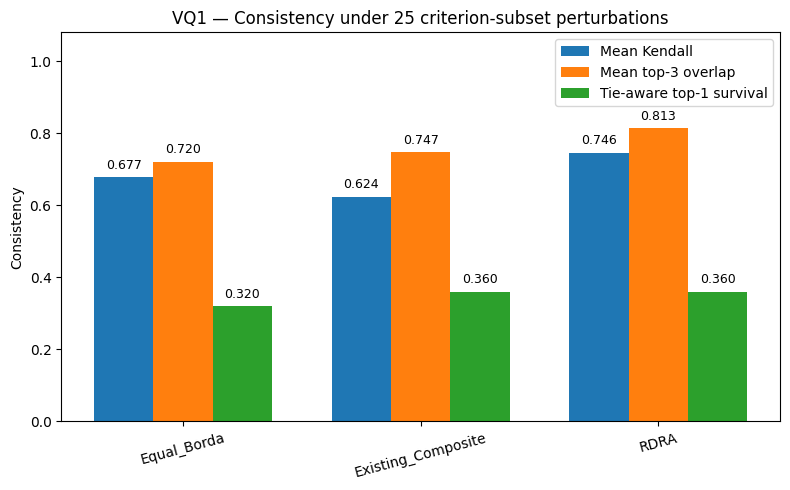

In [ ]:
# VQI Consistency Visualisation
# Visualise method-level consistency metrics
# Compare Existing Composite, Equal Borda, and RDRA

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(vq1_summary))
width = 0.25

# Plot Mean Kendall τ
bars1 = ax.bar(
    x - width,
    vq1_summary["Mean_Kendall"],
    width,
    label="Mean Kendall",
)

# Plot Mean Top-3 Overlap
bars2 = ax.bar(
    x,
    vq1_summary["Mean_Top3_Overlap"],
    width,
    label="Mean top-3 overlap",
)

# Plot Tie-Aware Top-1 Survival
bars3 = ax.bar(
    x + width,
    vq1_summary["Tie_Aware_Winner_Survival"],
    width,
    label="Tie-aware top-1 survival",
)

# Add value labels above each bar
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()

        ax.annotate(
            f"{height:.3f}",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                height,
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

# Axis formatting
ax.set_xticks(x)

ax.set_xticklabels(vq1_summary["Method"], rotation=15)

# Slightly increase upper limit so labels do not touch the top
ax.set_ylim(0, 1.08)

ax.set_ylabel("Consistency")

ax.set_title("VQ1 — Consistency under 25 criterion-subset perturbations")
ax.legend()
fig.tight_layout()

fig.savefig(
    FIG / "vq1_criterion_subset_consistency.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## VQ1 additional validation- Leave‑One‑Dimension‑Out (LOO) Influence Analysis

This subsection evaluates **dimension‑level influence** on RDRA’s final ranking.

For each deployment dimension *d*:
1. Remove *d* from the dimension set.  
2. Recompute RDRA using the remaining 4 dimensions.  
3. Compare the resulting ranking against the full 5‑dimension RDRA ranking.  
4. Measure:
   - Kendall τ agreement  
   - Spearman ρ agreement  
   - Mean absolute rank displacement  
   - Top‑3 overlap  
   - Tie‑aware top‑1 survival  

This analysis identifies:
- which dimensions RDRA depends on most,  
- which dimensions have minimal influence,  
- whether RDRA is robust to dimension removal.


In [ ]:
loo_rows = []

for removed in AI_DIMS:
    # Remaining dimensions after removing one
    dims = [d for d in AI_DIMS if d != removed]

    # RDRA under reduced dimension set
    rr = rank_under_subset(
        ai_scores,
        "Variant",
        dims,
        "rdra",
        ai_reliability_weights,
    )

    rr_map = dict(zip(
        rr["Variant"],
        rr["Rank"],
    ))

    # Compare reduced RDRA ranking to full RDRA ranking
    metrics = compare_rank_maps(
        full_maps["RDRA"],
        rr_map,
        top_k=3,
    )

    loo_rows.append({
        "Removed_Dimension": removed,
        **metrics,
    })

# Build LOO influence table
vq1_rdra_loo = pd.DataFrame(loo_rows).sort_values(
    [
        "Kendall_Agreement",
        "Mean_Absolute_Rank_Displacement",
    ],
    ascending=[True, False],
)

# Export results
vq1_rdra_loo.to_csv(
    OUT / "04_vq1_rdra_leave_one_dimension_out.csv",
    index=False,
)

display(vq1_rdra_loo)

,Removed_Dimension,Kendall_Agreement,Spearman_Agreement,Mean_Absolute_Rank_Displacement,Top3_Overlap,Winner_Survived,Top1_Set_Overlap,Subset_Winner_Set,Full_Winner_Set
2,Reliability,0.830065,0.950464,1.222222,1.0,True,1.0,XGBoost | none | platt,XGBoost | none | platt
0,Predictive,0.843137,0.954592,1.222222,1.0,False,0.0,XGBoost | none | none,XGBoost | none | platt
3,Efficiency,0.856209,0.958720,1.111111,1.0,False,0.0,XGBoost | none | none,XGBoost | none | platt
1,Robustness,0.960784,0.993808,0.333333,1.0,True,1.0,XGBoost | none | platt,XGBoost | none | platt
4,Operational,0.960784,0.993808,0.333333,1.0,False,0.0,XGBoost | none | none,XGBoost | none | platt


##  VQ1 - Deployment‑Dominance Consistency

This subsection evaluates whether each ranking method respects **deployment‑evidence
dominance**.

A candidate A *dominates* candidate B if:
- A ≥ B on **all** deployment dimensions, and  
- A > B on **at least one** dimension.

A valid deployment‑aligned ranking must **not** place B above A in such cases.

This is a fundamental sanity check:
- independent of stakeholder preferences,  
- independent of aggregation weights,  
- independent of perturbation design.

It ensures that the ranking does not contradict the underlying deployment evidence.

Outputs:
- a summary table showing dominance‑consistency metrics for each method,  
- detailed violation lists for each method.


In [ ]:
# VQ1 Deployment-Dominance Consistency

dominance_rows = []
dominance_details = {}

# Evaluate dominance consistency for each ranking method
for method_name, rank_df, rank_col in [
    ("Existing_Composite", existing, "Existing_Composite_Rank"),
    ("Equal_Borda",       equal_borda, "Equal_Borda_Rank"),
    ("RDRA",              rdra, "RDRA_Rank"),
]:
    # Compute dominance consistency summary + violation detail
    summary, detail = dominance_consistency(
        ai_scores,      # raw dimension scores
        rank_df,        # ranking table
        "Variant",      # candidate identifier
        rank_col,       # ranking column
        AI_DIMS,        # deployment dimensions
    )

    dominance_rows.append({
        "Method": method_name,
        **summary,
    })

    dominance_details[method_name] = detail

# Build summary table
dominance_summary = pd.DataFrame(dominance_rows)

dominance_summary.to_csv(
    OUT / "05_vq1_deployment_dominance_consistency.csv",
    index=False,
)

for method_name, detail in dominance_details.items():
    detail.to_csv(
        OUT / f"05b_{method_name}_dominance_violations.csv",
        index=False,
    )

display(dominance_summary)

,Method,Comparable_Dominance_Pairs,Violations,Violation_Rate,Dominance_Consistency
0,Existing_Composite,9,0,0.0,1.0
1,Equal_Borda,9,0,0.0,1.0
2,RDRA,9,0,0.0,1.0


## VQ2 - Data Quality Uncertainty -> Evidence‑Change Responsiveness (Fixed Clean‑Data Normalisation)

VQ2 evaluates how RDRA responds when the *evidence itself* changes due to corruption
conditions.  
Unlike VQ1 (criterion‑subset perturbations), VQ2 tests **evidence perturbations**:
changes in F1, PR‑AUC, robustness retention, and operational cost under different
corruption conditions and severity levels.

To ensure leakage‑free evaluation, **all corrupted evidence is normalised using
clean‑data min/max bounds**:

- Predictive (F1, PR‑AUC) → fixed clean‑data benefit normalisation  
- Operational cost → fixed clean‑data cost normalisation  
- Reliability and Efficiency → held fixed at clean values  
- Robustness → corruption‑specific F1‑retention clipped to [0, 1]

This ensures:
- corrupted evidence does **not** influence the normalisation scale,  
- responsiveness is measured relative to the clean baseline,  
- comparisons remain fair and interpretable.

For each corruption condition and level, VQ2 computes:

- Kendall τ and Spearman ρ agreement with clean RDRA  
- mean absolute rank displacement  
- magnitude of evidence change  
- tie‑aware top‑1 survival  
- top‑3 set overlap  

This quantifies whether RDRA reacts appropriately to meaningful evidence changes.


In [ ]:
# Load raw corruption robustness evidence
ai_robust_raw = pd.read_csv(
    require(AI4I_BASE / "02_robustness_raw_results.csv")
)

# Clean RDRA reference ranking
clean_rdra_map = dict(zip(
    rdra["Variant"],
    rdra["RDRA_Rank"],
))
clean_winner_set = top_rank_set(clean_rdra_map)
clean_top3 = top_k_set_from_map(clean_rdra_map, k=3)

# Aggregate corruption evidence by (Variant, Condition, Level)
corruption_agg = (
    ai_robust_raw
    .groupby(
        ["Variant", "Condition", "Level"],
        as_index=False,
    )
    .agg(
        F1=("F1", "mean"),
        PR_AUC=("PR_AUC", "mean"),
        Operational_Cost=("Operational_Cost", "mean"),
        F1_Retention=("F1_Retention", "mean"),
    )
)

# Fixed clean-data normalisation bounds (leakage-free)
ai_bounds = {
    "F1": (
        float(ai_candidate["F1"].min()),
        float(ai_candidate["F1"].max()),
    ),
    "PR_AUC": (
        float(ai_candidate["PR_AUC"].min()),
        float(ai_candidate["PR_AUC"].max()),
    ),
    "Operational_Cost": (
        float(ai_candidate["Operational_Cost"].min()),
        float(ai_candidate["Operational_Cost"].max()),
    ),
}

# Clean reliability and efficiency lookups (held fixed)
clean_reliability_lookup = dict(zip(
    ai_scores["Variant"],
    ai_scores["Reliability"],
))
clean_efficiency_lookup = dict(zip(
    ai_scores["Variant"],
    ai_scores["Efficiency"],
))

# Clean score reference matrix
clean_score_reference = (
    ai_scores
    .set_index("Variant")[AI_DIMS]
)

vq2_rows = []

# Evaluate responsiveness for each corruption condition + level
for (condition, level), g in corruption_agg.groupby(["Condition", "Level"]):
    g = g.copy()

    # Build scenario score table using fixed clean-data normalisation
    scenario_scores = pd.DataFrame({
        "Variant": g["Variant"],

        # Predictive: fixed clean-data benefit normalisation
        "Predictive": (
            fixed_benefit(g["F1"], *ai_bounds["F1"]).to_numpy()
            + fixed_benefit(g["PR_AUC"], *ai_bounds["PR_AUC"]).to_numpy()
        ) / 2.0,

        # Robustness: corruption-specific retention (clipped)
        "Robustness": pd.Series(g["F1_Retention"], dtype=float)
            .clip(0, 1).to_numpy(),

        # Reliability: held fixed at clean values
        "Reliability": g["Variant"].map(clean_reliability_lookup).to_numpy(),

        # Efficiency: held fixed at clean values
        "Efficiency": g["Variant"].map(clean_efficiency_lookup).to_numpy(),

        # Operational: fixed clean-data cost normalisation
        "Operational": fixed_cost(
            g["Operational_Cost"],
            *ai_bounds["Operational_Cost"],
        ).to_numpy(),
    })

    # Rank scenario using RDRA
    scenario_rank_table = make_dimension_rank_table(
        scenario_scores,
        "Variant",
        AI_DIMS,
    )

    scenario_rdra, _ = aggregate_borda(
        scenario_rank_table,
        "Variant",
        AI_DIMS,
        ai_reliability_weights,
        "RDRA",
    )

    scenario_map = dict(zip(
        scenario_rdra["Variant"],
        scenario_rdra["RDRA_Rank"],
    ))

    # Compare scenario ranking vs clean ranking
    common = sorted(set(clean_rdra_map) & set(scenario_map))

    clean_rank_vector = np.array(
        [clean_rdra_map[v] for v in common],
        dtype=float,
    )
    scenario_rank_vector = np.array(
        [scenario_map[v] for v in common],
        dtype=float,
    )

    scenario_top1 = top_rank_set(
        {v: scenario_map[v] for v in common}
    )
    scenario_top3 = top_k_set_from_map(
        {v: scenario_map[v] for v in common},
        k=3,
    )

    # Evidence-change magnitude (mean absolute difference)
    scenario_score_reference = (
        scenario_scores
        .set_index("Variant")[AI_DIMS]
        .loc[common]
    )

    clean_matrix = clean_score_reference.loc[common].to_numpy(dtype=float)
    scenario_matrix = scenario_score_reference.to_numpy(dtype=float)

    evidence_change = float(np.mean(np.abs(clean_matrix - scenario_matrix)))
    rank_change = float(np.mean(np.abs(clean_rank_vector - scenario_rank_vector)))

    # Store VQ2 metrics
    vq2_rows.append({
        "Condition": condition,
        "Level": float(level),
        "Kendall_DRS": kendall_rank_agreement(
            clean_rank_vector,
            scenario_rank_vector,
        ),
        "Spearman_DRS": spearman_rank_agreement(
            clean_rank_vector,
            scenario_rank_vector,
        ),
        "Mean_Rank_Displacement": rank_change,
        "Evidence_Change_Magnitude": evidence_change,
        "Tie_Aware_Top1_Survival": bool(
            clean_winner_set & scenario_top1
        ),
        "Top3_Set_Overlap": (
            len(clean_top3 & scenario_top3) / 3.0
        ),
        "Scenario_Winner_Set": " | ".join(
            sorted(map(str, scenario_top1))
        ),
        "Clean_Winner_Set": " | ".join(
            sorted(map(str, clean_winner_set))
        ),
    })

# Build VQ2 results table
vq2_ai4i = pd.DataFrame(vq2_rows)

vq2_ai4i.to_csv(
    OUT / "06_vq2_ai4i_fixed_clean_responsiveness.csv",
    index=False,
)

display(vq2_ai4i.head())

,Condition,Level,Kendall_DRS,Spearman_DRS,Mean_Rank_Displacement,Evidence_Change_Magnitude,Tie_Aware_Top1_Survival,Top3_Set_Overlap,Scenario_Winner_Set,Clean_Winner_Set
0,Gaussian Noise,0.05,0.908497,0.971104,0.666667,0.227783,True,1.0,XGBoost | none | platt,XGBoost | none | platt
1,Gaussian Noise,0.10,0.882353,0.971104,0.888889,0.301766,False,1.0,XGBoost | none | none,XGBoost | none | platt
2,Gaussian Noise,0.20,0.803922,0.917441,1.555556,0.321858,False,1.0,XGBoost | none | none,XGBoost | none | platt
3,Gaussian Noise,0.30,0.790850,0.919505,1.666667,0.305759,False,1.0,XGBoost | none | none,XGBoost | none | platt
4,Missing Values MCAR,0.05,0.908497,0.966976,0.666667,0.269785,True,1.0,XGBoost | none | platt,XGBoost | none | platt


##  VQ2 - Responsiveness Summary and Evidence-Change Correlation

This subsection aggregates VQ2 results to produce two key interpretability outputs:

#### 1. Condition‑Level Responsiveness Summary  
For each corruption condition (e.g., Gaussian noise, blur, occlusion), compute:

- mean Kendall τ agreement with clean RDRA,  
- mean rank displacement,  
- mean evidence‑change magnitude,  
- tie‑aware top‑1 survival rate,  
- mean top‑3 overlap.

This shows which corruption types produce the strongest ranking changes.

#### 2. Global Evidence‑Change vs Rank‑Change Correlation  
Compute Spearman correlation between:

- **Evidence_Change_Magnitude**  
- **Mean_Rank_Displacement**

A positive correlation indicates that **larger evidence changes tend to produce larger
ranking changes**, which is the expected behaviour of a responsive ranking method.

This correlation is a direct quantitative measure of RDRA’s responsiveness.


In [ ]:
# Global Spearman correlation between evidence change and rank change
if len(vq2_ai4i) >= 3:
    responsiveness_rho, responsiveness_p = spearmanr(
        vq2_ai4i["Evidence_Change_Magnitude"],
        vq2_ai4i["Mean_Rank_Displacement"],
    )
else:
    responsiveness_rho, responsiveness_p = np.nan, np.nan

# Condition-level responsiveness summary
vq2_condition_summary = (
    vq2_ai4i
    .groupby("Condition", as_index=False)
    .agg(
        Mean_Kendall=("Kendall_DRS", "mean"),
        Mean_Rank_Displacement=("Mean_Rank_Displacement", "mean"),
        Mean_Evidence_Change=("Evidence_Change_Magnitude", "mean"),
        Tie_Aware_Top1_Survival=("Tie_Aware_Top1_Survival", "mean"),
        Mean_Top3_Overlap=("Top3_Set_Overlap", "mean"),
    )
)

# Global responsiveness interpretation table
vq2_responsiveness_summary = pd.DataFrame([{
    "Spearman_EvidenceChange_vs_RankChange":
        float(responsiveness_rho)
        if not np.isnan(responsiveness_rho)
        else np.nan,
    "P_Value":
        float(responsiveness_p)
        if not np.isnan(responsiveness_p)
        else np.nan,
    "Interpretation":
        (
            "Positive association means larger evidence changes "
            "tend to produce larger ranking changes."
        ),
}])

# Export results
vq2_condition_summary.to_csv(
    OUT / "06b_vq2_ai4i_condition_summary.csv",
    index=False,
)
vq2_responsiveness_summary.to_csv(
    OUT / "06c_vq2_evidence_rank_responsiveness.csv",
    index=False,
)

display(vq2_condition_summary)
display(vq2_responsiveness_summary)

,Condition,Mean_Kendall,Mean_Rank_Displacement,Mean_Evidence_Change,Tie_Aware_Top1_Survival,Mean_Top3_Overlap
0,Gaussian Noise,0.846405,1.194444,0.289292,0.25,1.000000
1,Missing Values MCAR,0.816993,1.444444,0.306745,0.25,1.000000
2,Outliers,0.810458,1.416667,0.299470,0.25,1.000000
3,Static Sensor Offset,0.882353,0.972222,0.295562,0.25,0.916667


,Spearman_EvidenceChange_vs_RankChange,P_Value,Interpretation
0,0.635696,0.008129,Positive association means larger evidence cha...


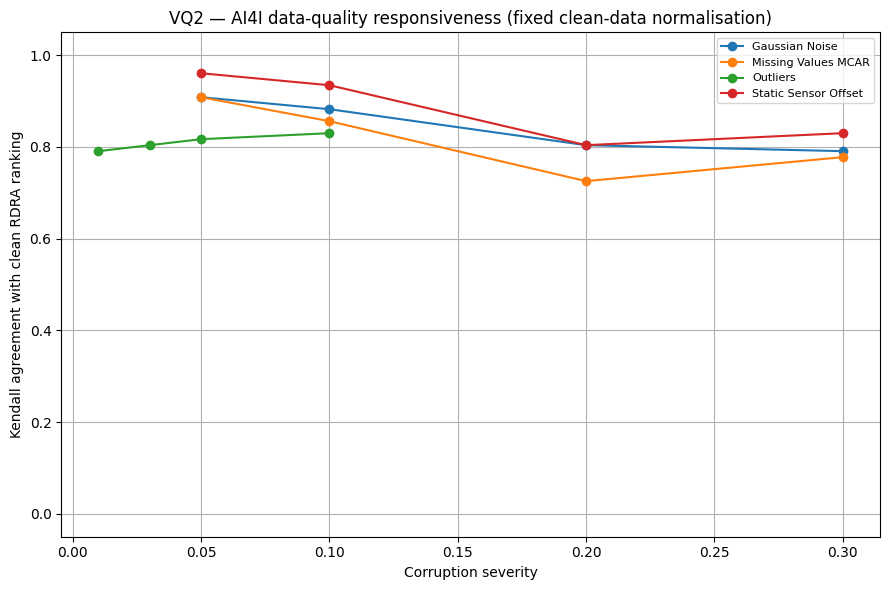

In [ ]:
# VQ2 Responsiveness Visualisation
plt.figure(figsize=(9, 6))

# Plot each corruption condition as a separate line
for condition, g in vq2_ai4i.groupby("Condition"):
    g = g.sort_values("Level")
    plt.plot(
        g["Level"],
        g["Kendall_DRS"],
        marker="o",
        label=condition,
    )

# Axis labels and formatting
plt.xlabel("Corruption severity")
plt.ylabel("Kendall agreement with clean RDRA ranking")
plt.title(
    "VQ2 — AI4I data-quality responsiveness "
    "(fixed clean-data normalisation)"
)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(
    FIG / "vq2_ai4i_fixed_clean_responsiveness.png",
    dpi=300,
)
plt.show()

## VQ2 — Sensitivity Analysis: Adaptive vs Fixed Normalisation

This subsection performs **secondary sensitivity validation** to compare:

1. **Fixed clean‑data normalisation**  
   (the *primary* VQ2 method, leakage‑free, used for the main results)

2. **Adaptive normalisation**  
   (normalisation recomputed using corruption‑perturbed evidence)

Adaptive normalisation is *not* used in the main RDRA evaluation because:

- it introduces leakage (corrupted evidence changes the normalisation scale),  
- it makes responsiveness harder to interpret,  
- it can artificially inflate or suppress dimension scores.

However, comparing fixed vs adaptive normalisation is valuable as a **robustness check**:

- If RDRA is stable under both, it shows robustness to normalisation choice.  
- If RDRA differs meaningfully, it shows that fixed clean‑data normalisation is necessary
  for fair, interpretable responsiveness evaluation.

This sensitivity analysis computes:

- Kendall agreement (adaptive vs clean RDRA)  
- top‑1 survival under adaptive normalisation  
- winner‑set changes  
- Δ Kendall (fixed − adaptive)

The final table highlights whether normalisation choice changes the ranking behaviour.


In [ ]:
adaptive_rows = []

# Clean static values for reliability and efficiency (held fixed)
clean_static = ai_candidate[
    [
        "Variant",
        "Brier",
        "ECE",
        "Single_Sample_Latency_Median_ms",
        "Model_Size_MB",
    ]
].copy()

# Adaptive normalisation: recompute min/max using corrupted evidence
for (condition, level), g in corruption_agg.groupby(["Condition", "Level"]):
    g = g.merge(clean_static, on="Variant", how="left")

    # Adaptive normalisation (minmax_benefit / minmax_cost)
    scenario_scores = pd.DataFrame({
        "Variant": g["Variant"],

        # Predictive: adaptive normalisation
        "Predictive": (
            minmax_benefit(g["F1"])
            + minmax_benefit(g["PR_AUC"])
        ) / 2.0,

        # Robustness: adaptive normalisation
        "Robustness": minmax_benefit(g["F1_Retention"]),

        # Reliability: adaptive normalisation
        "Reliability": (
            minmax_cost(g["Brier"])
            + minmax_cost(g["ECE"])
        ) / 2.0,

        # Efficiency: adaptive normalisation
        "Efficiency": (
            minmax_cost(g["Single_Sample_Latency_Median_ms"])
            + minmax_cost(g["Model_Size_MB"])
        ) / 2.0,

        # Operational: adaptive normalisation
        "Operational": minmax_cost(g["Operational_Cost"]),
    })

    scenario_rank_table = make_dimension_rank_table(
        scenario_scores,
        "Variant",
        AI_DIMS,
    )

    scenario_rdra, _ = aggregate_borda(
        scenario_rank_table,
        "Variant",
        AI_DIMS,
        ai_reliability_weights,
        "RDRA",
    )

    scenario_map = dict(zip(
        scenario_rdra["Variant"],
        scenario_rdra["RDRA_Rank"],
    ))

    common = sorted(set(clean_rdra_map) & set(scenario_map))
    a = [clean_rdra_map[v] for v in common]
    b = [scenario_map[v] for v in common]

    scenario_top1 = top_rank_set({v: scenario_map[v] for v in common})

    adaptive_rows.append({
        "Condition": condition,
        "Level": float(level),
        "Adaptive_Kendall_DRS": kendall_rank_agreement(a, b),
        "Adaptive_Top1_Survival": bool(clean_winner_set & scenario_top1),
        "Adaptive_Winner_Set": " | ".join(sorted(map(str, scenario_top1))),
    })

vq2_adaptive = pd.DataFrame(adaptive_rows)

# Compare fixed vs adaptive normalisation
vq2_norm_compare = (
    vq2_ai4i[
        [
            "Condition",
            "Level",
            "Kendall_DRS",
            "Tie_Aware_Top1_Survival",
            "Scenario_Winner_Set",
        ]
    ]
    .rename(columns={
        "Kendall_DRS": "Fixed_Kendall_DRS",
        "Tie_Aware_Top1_Survival": "Fixed_Top1_Survival",
        "Scenario_Winner_Set": "Fixed_Winner_Set",
    })
    .merge(vq2_adaptive, on=["Condition", "Level"], how="inner")
)

# Δ Kendall (fixed − adaptive)
vq2_norm_compare["Delta_Kendall_Fixed_minus_Adaptive"] = (
    vq2_norm_compare["Fixed_Kendall_DRS"]
    - vq2_norm_compare["Adaptive_Kendall_DRS"]
)

# Winner-set change indicator
vq2_norm_compare["Winner_Set_Changed_By_Normalisation"] = (
    vq2_norm_compare["Fixed_Winner_Set"]
    != vq2_norm_compare["Adaptive_Winner_Set"]
)

# Export sensitivity comparison
vq2_norm_compare.to_csv(
    OUT / "07_vq2_normalisation_sensitivity.csv",
    index=False,
)

display(vq2_norm_compare.head())

,Condition,Level,Fixed_Kendall_DRS,Fixed_Top1_Survival,Fixed_Winner_Set,Adaptive_Kendall_DRS,Adaptive_Top1_Survival,Adaptive_Winner_Set,Delta_Kendall_Fixed_minus_Adaptive,Winner_Set_Changed_By_Normalisation
0,Gaussian Noise,0.05,0.908497,True,XGBoost | none | platt,0.908497,True,XGBoost | none | platt,0.000000,False
1,Gaussian Noise,0.10,0.882353,False,XGBoost | none | none,0.973856,False,XGBoost | none | none,-0.091503,False
2,Gaussian Noise,0.20,0.803922,False,XGBoost | none | none,0.869281,True,XGBoost | none | platt,-0.065359,True
3,Gaussian Noise,0.30,0.790850,False,XGBoost | none | none,0.803922,True,XGBoost | none | platt,-0.013072,True
4,Missing Values MCAR,0.05,0.908497,True,XGBoost | none | platt,0.843137,True,XGBoost | none | platt,0.065359,False


## VQ3 - Preference Uncertainty → Downstream Decision Usefulness

VQ3 evaluates whether RDRA produces rankings that are *actually useful* for
deployment decisions when stakeholder preferences are uncertain.

This revision strengthens the original regret analysis by adding a **direct link back
to the ranking method**:

#### Level 1 — Downstream decision‑risk analysis  
Evaluate minimax regret over the feasible, Pareto‑efficient candidates.  
This tests whether RDRA’s top‑ranked candidates remain low‑regret under thousands of
possible preference scenarios.

#### Level 2 — Ranking usefulness test  
Compare the top‑k shortlists produced by:
- **RDRA**,  
- **Equal Borda**,  

and test whether RDRA’s shortlist contains **lower‑regret options** under preference
uncertainty.

This makes VQ3 directly relevant to the Main RQ:  
**Does RDRA produce rankings that meaningfully reduce deployment decision‑risk?**

Before regret analysis, VQ3 first identifies:
- feasible candidates under operational constraints,  
- Pareto‑efficient candidates under multi‑objective deployment evidence.

Only these candidates are considered for regret analysis.


In [ ]:
AI_OBJECTIVES = {
    "F1": "max",
    "Composite_Corruption_Robustness_Mean": "max",
    "Operational_Cost": "min",
    "Single_Sample_Latency_Median_ms": "min",
}

# Experimental feasibility constraints
experimental_constraints = {
    "Recall": (
        ">=",
        max(
            0.80,
            float(
                ai_candidate["Recall"].quantile(0.40)
            ),
        ),
    ),
    "Composite_Corruption_Robustness_Mean": (
        ">=",
        float(
            ai_candidate[
                "Composite_Corruption_Robustness_Mean"
            ].quantile(0.35)
        ),
    ),
    "Single_Sample_Latency_Median_ms": (
        "<=",
        float(
            ai_candidate[
                "Single_Sample_Latency_Median_ms"
            ].quantile(0.75)
        ),
    ),
    "ECE": (
        "<=",
        max(
            0.02,
            float(
                ai_candidate["ECE"].quantile(0.50)
            ),
        ),
    ),
}

# Apply feasibility constraints
feasible = apply_constraints(ai_candidate, experimental_constraints)

# Pareto filtering under deployment objectives
feasible["Pareto_Efficient"] = pareto_mask(feasible, AI_OBJECTIVES)

pareto = feasible[feasible["Pareto_Efficient"]].copy()

print("Feasible candidates:", len(feasible))
print("Pareto candidates:", len(pareto))

display(pareto[["Variant", *AI_OBJECTIVES.keys()]])

Feasible candidates: 4
Pareto candidates: 4


,Variant,F1,Composite_Corruption_Robustness_Mean,Operational_Cost,Single_Sample_Latency_Median_ms
0,Random Forest | class_weight | isotonic,0.586499,0.793601,133.05,47.453592
2,Random Forest | class_weight | platt,0.584962,0.794893,133.85,47.623069
9,XGBoost | class_weight | isotonic,0.654247,0.779660,131.95,5.851255
11,XGBoost | class_weight | platt,0.649438,0.780461,132.25,8.876353


In [ ]:
# Minimax Regret Under Preference Uncertainty
# - Sample 5,000 preference weight vectors.
# - Compute minimax regret over Pareto-efficient candidates.
# - Produce regret summary for downstream decision-risk analysis.

N_WEIGHT_SAMPLES = 5000

# Draw random preference weight vectors from symmetric Dirichlet
weight_samples = rng.dirichlet(
    np.ones(len(AI_OBJECTIVES)),
    size=N_WEIGHT_SAMPLES,
)

# Compute minimax regret over Pareto-efficient candidates
rmrs_summary, rmrs_regret_matrix = minimax_regret(
    pareto,
    "Variant",
    AI_OBJECTIVES,
    weight_samples,
)

# Export regret summary
rmrs_summary.to_csv(
    OUT / "08_vq3_pareto_minimax_regret_summary.csv",
    index=False,
)

display(rmrs_summary)

,Variant,Mean_Regret,P95_Regret,Worst_Case_Regret,Zero_Regret_Frequency,Robust_Regret_Rank
3,XGBoost | class_weight | platt,0.096088,0.287290,0.887321,0.0000,1
2,XGBoost | class_weight | isotonic,0.033974,0.278828,0.933845,0.8576,2
0,Random Forest | class_weight | isotonic,0.447315,0.873045,0.991296,0.0740,3
1,Random Forest | class_weight | platt,0.538289,0.969837,0.999690,0.0684,4


## VQ3 - Ranking‑Usefulness Test

This subsection evaluates whether the ranking produced by RDRA is *more useful* for
downstream decision‑making under preference uncertainty than Equal Borda or the
Existing Composite.

The test proceeds as follows:

1. **Take the top‑3 feasible candidates** from each ranking method  
   (Existing Composite, Equal Borda, RDRA).

2. For each of the 5,000 preference‑weight samples used in the minimax‑regret
   analysis:
   - compute regret for each candidate in the shortlist,
   - allow the shortlist to choose its *best* candidate under that preference,
   - record the resulting residual regret.

3. Summarise shortlist performance using:
   - mean regret,  
   - 95th‑percentile regret,  
   - CVaR‑95 (tail conditional regret),  
   - worst‑case regret,  
   - zero‑regret frequency.

A ranking method is **more decision‑useful** if its top‑3 shortlist contains
candidates that collectively achieve **lower regret** across preference scenarios.

This test directly links the ranking method to downstream decision‑risk and provides
a clear, interpretable measure of usefulness.


In [ ]:
feasible_names = set(feasible["Variant"])

def method_top_k_feasible(rank_df, id_col, rank_col, feasible_names, k=3):
    """
    Extract the top-k feasible candidates from a ranking method.
    """
    temp = rank_df[rank_df[id_col].isin(feasible_names)].copy()
    temp = temp.sort_values([rank_col, id_col])
    return temp.head(k)[id_col].tolist()

# Regret across all feasible candidates under preference uncertainty
feasible_regret = regret_matrix_for_candidates(
    feasible,
    AI_OBJECTIVES,
    weight_samples,
)

feasible_name_list = feasible["Variant"].tolist()
feasible_index = {
    name: i
    for i, name in enumerate(feasible_name_list)
}

# Build top-3 feasible shortlists for each ranking method
ranking_shortlists = {
    "Equal_Borda": method_top_k_feasible(
        equal_borda,
        "Variant",
        "Equal_Borda_Rank",
        feasible_names,
        k=3,
    ),
    "RDRA": method_top_k_feasible(
        rdra,
        "Variant",
        "RDRA_Rank",
        feasible_names,
        k=3,
    ),
    "Existing_Composite": method_top_k_feasible(
        existing,
        "Variant",
        "Existing_Composite_Rank",
        feasible_names,
        k=3,
    ),
}

shortlist_rows = []

# Evaluate regret for each shortlist
for method, shortlist in ranking_shortlists.items():
    idx = [feasible_index[name] for name in shortlist]

    # Regret matrix restricted to shortlist candidates
    shortlist_regret = feasible_regret[idx, :]

    # Best candidate in shortlist under each preference scenario
    best_shortlist_regret = shortlist_regret.min(axis=0)

    # Summary metrics
    q95 = float(np.quantile(best_shortlist_regret, 0.95))
    tail = best_shortlist_regret[best_shortlist_regret >= q95]

    shortlist_rows.append({
        "Method": method,
        "Top3_Feasible_Shortlist": " | ".join(shortlist),
        "Mean_Shortlist_Regret": float(best_shortlist_regret.mean()),
        "P95_Shortlist_Regret": q95,
        "CVaR95_Shortlist_Regret": float(tail.mean()) if len(tail) else q95,
        "Worst_Case_Shortlist_Regret": float(best_shortlist_regret.max()),
        "Zero_Regret_Frequency": float(
            np.mean(np.isclose(best_shortlist_regret, 0.0, atol=1e-12))
        ),
    })

# Build shortlist usefulness table
vq3_shortlist_usefulness = (
    pd.DataFrame(shortlist_rows)
    .sort_values(["Worst_Case_Shortlist_Regret", "Mean_Shortlist_Regret"])
)

vq3_shortlist_usefulness.to_csv(
    OUT / "09_vq3_ranking_shortlist_decision_usefulness.csv",
    index=False,
)

display(vq3_shortlist_usefulness)

,Method,Top3_Feasible_Shortlist,Mean_Shortlist_Regret,P95_Shortlist_Regret,CVaR95_Shortlist_Regret,Worst_Case_Shortlist_Regret,Zero_Regret_Frequency
0,Equal_Borda,XGBoost | class_weight | isotonic | XGBoost | ...,0.002069,0.016802,0.038217,0.079113,0.9316
1,RDRA,XGBoost | class_weight | isotonic | XGBoost | ...,0.002069,0.016802,0.038217,0.079113,0.9316
2,Existing_Composite,XGBoost | class_weight | platt | XGBoost | cla...,0.003082,0.019930,0.057028,0.139577,0.9260


## VQ3 - Joint Preference + Corruption Regret Analysis

This subsection extends VQ3 by evaluating regret under **joint uncertainty**:

1. **Preference uncertainty**  
   (random weight vectors over deployment objectives)

2. **Corruption uncertainty**  
   (different corruption conditions and severity levels)

The goal is to test whether Pareto‑efficient candidates remain low‑regret when both:

- stakeholder preferences vary, and  
- data‑quality conditions degrade.

#### Procedure

1. Construct scenario tables:
   - Clean scenario (baseline)
   - One scenario per corruption condition × severity level  
     (F1, robustness retention, operational cost updated; latency fixed)

2. For each scenario:
   - compute regret under 2,000 preference samples,  
   - record regret for every Pareto candidate under every preference sample.

3. Summarise joint regret:
   - mean regret  
   - 95th‑percentile regret  
   - worst‑case regret  
   - zero‑regret frequency  
   - robust regret rank (minimising worst‑case regret)

This produces a **joint robustness ranking** that identifies candidates that remain
strong across both preference and corruption uncertainty.


In [ ]:
pareto_variants = set(pareto["Variant"])

# Restrict corruption evidence to Pareto candidates only
corruption_for_regret = corruption_agg[
    corruption_agg["Variant"].isin(pareto_variants)
].copy()

# Latency lookup (fixed across corruption scenarios)
latency_lookup = dict(zip(
    ai_candidate["Variant"],
    ai_candidate["Single_Sample_Latency_Median_ms"],
))

scenario_tables = []

# Clean scenario (baseline)
clean_scenario = pareto[
    [
        "Variant",
        "F1",
        "Composite_Corruption_Robustness_Mean",
        "Operational_Cost",
        "Single_Sample_Latency_Median_ms",
    ]
].copy()

clean_scenario["Scenario"] = "Clean"
scenario_tables.append(clean_scenario)

# Corruption scenarios
for (condition, level), g in corruption_for_regret.groupby(["Condition", "Level"]):
    scenario = g[
        ["Variant", "F1", "F1_Retention", "Operational_Cost"]
    ].copy()

    # Rename retention → robustness
    scenario = scenario.rename(columns={
        "F1_Retention": "Composite_Corruption_Robustness_Mean"
    })

    # Latency remains fixed (clean)
    scenario["Single_Sample_Latency_Median_ms"] = scenario["Variant"].map(latency_lookup)

    # Scenario name
    scenario["Scenario"] = f"{condition} | {level}"

    scenario_tables.append(scenario)

# Combine all scenarios
all_scenarios = pd.concat(scenario_tables, ignore_index=True)

candidate_names = pareto["Variant"].tolist()

# Preference uncertainty samples
N_JOINT_WEIGHT_SAMPLES = 2000

joint_weights = rng.dirichlet(
    np.ones(len(AI_OBJECTIVES)),
    size=N_JOINT_WEIGHT_SAMPLES,
)

joint_rows = []

# Compute regret for each scenario
for scenario_name, scenario_df in all_scenarios.groupby("Scenario"):
    scenario_df = (
        scenario_df
        .set_index("Variant")
        .reindex(candidate_names)
        .reset_index()
    )

    # Skip scenarios with missing values
    if scenario_df[list(AI_OBJECTIVES)].isna().any().any():
        continue

    regret = regret_matrix_for_candidates(
        scenario_df,
        AI_OBJECTIVES,
        joint_weights,
    )

    # Store regret for each candidate × weight sample
    for i, candidate_name in enumerate(candidate_names):
        for sample_index in range(N_JOINT_WEIGHT_SAMPLES):
            joint_rows.append({
                "Scenario": scenario_name,
                "Weight_Sample": sample_index,
                "Variant": candidate_name,
                "Regret": float(regret[i, sample_index]),
            })

joint_regret = pd.DataFrame(joint_rows)

# Summarise joint regret
joint_summary = (
    joint_regret
    .groupby("Variant", as_index=False)
    .agg(
        Mean_Joint_Regret=("Regret", "mean"),
        P95_Joint_Regret=("Regret", lambda x: float(np.quantile(x, 0.95))),
        Worst_Case_Joint_Regret=("Regret", "max"),
        Zero_Regret_Frequency=("Regret", lambda x: float(
            np.mean(np.isclose(x, 0.0, atol=1e-12))
        )),
    )
)

# Robust regret rank (minimising worst-case regret)
joint_summary["Joint_Robust_Regret_Rank"] = (
    joint_summary["Worst_Case_Joint_Regret"]
    .rank(ascending=True, method="min")
    .astype(int)
)

joint_summary = joint_summary.sort_values(
    ["Joint_Robust_Regret_Rank", "Mean_Joint_Regret"]
)

joint_summary.to_csv(
    OUT / "10_vq3_preference_corruption_regret_summary.csv",
    index=False,
)

display(joint_summary)

,Variant,Mean_Joint_Regret,P95_Joint_Regret,Worst_Case_Joint_Regret,Zero_Regret_Frequency,Joint_Robust_Regret_Rank
3,XGBoost | class_weight | platt,0.123966,0.560538,0.969285,0.089765,1
2,XGBoost | class_weight | isotonic,0.084179,0.534891,0.971801,0.686618,2
0,Random Forest | class_weight | isotonic,0.533107,0.981915,0.998236,0.043500,3
1,Random Forest | class_weight | platt,0.530673,1.000000,1.000000,0.180118,4


# Complementary cross-task evidence — C-MAPSS FD001

**Important scope statement:**  
The current C-MAPSS analysis does **not** estimate C-MAPSS-specific RDRA reliability weights because the required repeated criterion-level evidence is not available here in the same form as AI4I.

Therefore:
- **AI4I is the primary RDRA evaluation.**
- **C-MAPSS is complementary cross-task evidence for deployment-rank responsiveness under sensor corruption.**

This avoids overstating the cross-task validation.

In [ ]:
# Load candidate summary and corruption evidence
cm_candidate = pd.read_csv(
    require(CMAPSS_BASE / "06_candidate_summary.csv")
)
cm_robust_raw = pd.read_csv(
    require(CMAPSS_BASE / "02_robustness_raw.csv")
)

CM_DIMS = ["Predictive", "Robustness", "Efficiency"]

# Clean scenario scores (equal-weight normalisation)
cm_scores = pd.DataFrame({
    "Model": cm_candidate["Model"],

    # Predictive: RMSE, MAE, NASA Score → cost-normalised
    "Predictive": (
        minmax_cost(cm_candidate["RMSE"])
        + minmax_cost(cm_candidate["MAE"])
        + minmax_cost(cm_candidate["NASA_Score"])
    ) / 3.0,

    # Robustness: corruption robustness mean → benefit-normalised
    "Robustness": minmax_benefit(
        cm_candidate["Composite_Corruption_Robustness_Mean"]
    ),

    # Efficiency: latency + model size → cost-normalised
    "Efficiency": (
        minmax_cost(cm_candidate["Single_Sample_Latency_Median_ms"])
        + minmax_cost(cm_candidate["Model_Size_MB"])
    ) / 2.0,
})

# Clean equal-weight consensus ranking
cm_rank_table = make_dimension_rank_table(cm_scores, "Model", CM_DIMS)

cm_equal_consensus, _ = aggregate_borda(
    cm_rank_table,
    "Model",
    CM_DIMS,
    None,                # equal weights
    "Equal_Consensus",
)

cm_clean_map = dict(zip(
    cm_equal_consensus["Model"],
    cm_equal_consensus["Equal_Consensus_Rank"],
))

cm_clean_top1 = top_rank_set(cm_clean_map)

# Fixed clean-data bounds for corruption responsiveness
cm_bounds = {
    "RMSE": (
        float(cm_candidate["RMSE"].min()),
        float(cm_candidate["RMSE"].max()),
    ),
    "MAE": (
        float(cm_candidate["MAE"].min()),
        float(cm_candidate["MAE"].max()),
    ),
    "NASA_Score": (
        float(cm_candidate["NASA_Score"].min()),
        float(cm_candidate["NASA_Score"].max()),
    ),
}

cm_clean_eff_lookup = dict(zip(
    cm_scores["Model"],
    cm_scores["Efficiency"],
))

# Aggregate corruption evidence
cm_corruption_agg = (
    cm_robust_raw
    .groupby(
        ["Model", "Condition", "Level"],
        as_index=False,
    )
    .agg(
        RMSE=("RMSE", "mean"),
        MAE=("MAE", "mean"),
        NASA_Score=("NASA_Score", "mean"),
        RMSE_Retention=("RMSE_Retention", "mean"),
    )
)

cm_rows = []

# Responsiveness under corruption conditions
for (condition, level), g in cm_corruption_agg.groupby(["Condition", "Level"]):

    # Build corruption-conditioned scenario scores
    scenario_scores = pd.DataFrame({
        "Model": g["Model"],

        # Predictive: fixed clean-data cost normalisation
        "Predictive": (
            fixed_cost(g["RMSE"], *cm_bounds["RMSE"]).to_numpy()
            + fixed_cost(g["MAE"], *cm_bounds["MAE"]).to_numpy()
            + fixed_cost(g["NASA_Score"], *cm_bounds["NASA_Score"]).to_numpy()
        ) / 3.0,

        # Robustness: retention clipped to [0, 1]
        "Robustness": pd.Series(g["RMSE_Retention"], dtype=float).clip(0, 1).to_numpy(),

        # Efficiency: fixed clean-data efficiency
        "Efficiency": g["Model"].map(cm_clean_eff_lookup).to_numpy(),
    })

    # Rank under corruption scenario
    scenario_rank_table = make_dimension_rank_table(scenario_scores, "Model", CM_DIMS)

    scenario_consensus, _ = aggregate_borda(
        scenario_rank_table,
        "Model",
        CM_DIMS,
        None,                # equal weights
        "Equal_Consensus",
    )

    scenario_map = dict(zip(
        scenario_consensus["Model"],
        scenario_consensus["Equal_Consensus_Rank"],
    ))

    # Compare clean vs corruption-conditioned ranking
    common = sorted(set(cm_clean_map) & set(scenario_map))

    a = [cm_clean_map[m] for m in common]
    b = [scenario_map[m] for m in common]

    scenario_top1 = top_rank_set({m: scenario_map[m] for m in common})

    cm_rows.append({
        "Condition": condition,
        "Level": float(level),
        "Kendall_DRS": kendall_rank_agreement(a, b),
        "Spearman_DRS": spearman_rank_agreement(a, b),
        "Tie_Aware_Top1_Survival": bool(cm_clean_top1 & scenario_top1),
        "Scenario_Winner_Set": " | ".join(sorted(map(str, scenario_top1))),
        "Clean_Winner_Set": " | ".join(sorted(map(str, cm_clean_top1))),
    })

# Build cross-task responsiveness table
cm_vq2 = pd.DataFrame(cm_rows)

cm_vq2.to_csv(
    OUT / "11_cross_task_cmapss_responsiveness.csv",
    index=False,
)

display(cm_vq2.head())

,Condition,Level,Kendall_DRS,Spearman_DRS,Tie_Aware_Top1_Survival,Scenario_Winner_Set,Clean_Winner_Set
0,Gaussian_Noise,0.05,0.200000,0.000000,False,Ridge,XGBoost
1,Gaussian_Noise,0.10,0.000000,-0.100000,False,Ridge,XGBoost
2,Gaussian_Noise,0.20,0.316228,0.205196,True,Ridge | XGBoost,XGBoost
3,Gaussian_Noise,0.30,0.800000,0.900000,True,XGBoost,XGBoost
4,Gradual_Offset_Drift,0.05,0.000000,0.100000,True,XGBoost,XGBoost


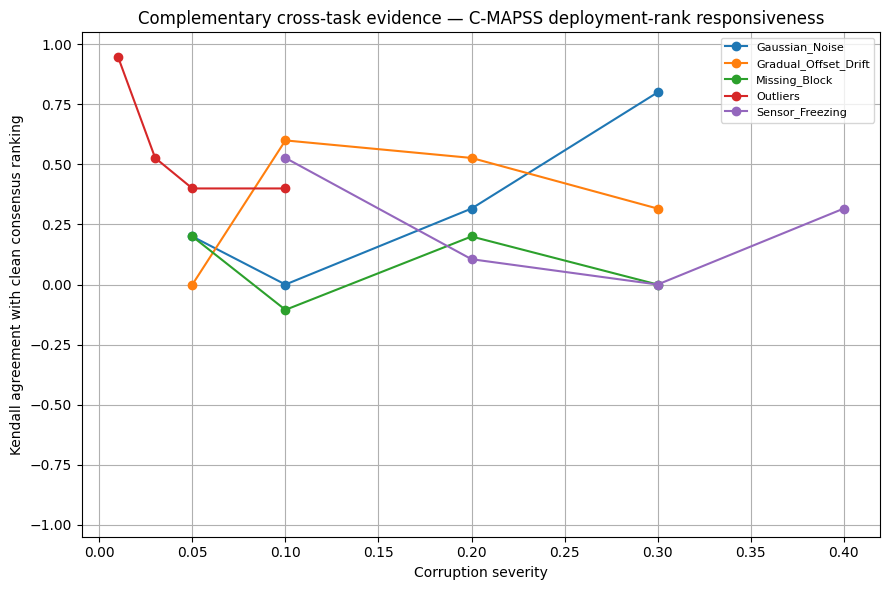

In [ ]:
plt.figure(figsize=(9, 6))

# Plot each corruption condition
for condition, g in cm_vq2.groupby("Condition"):
    g = g.sort_values("Level")
    plt.plot(
        g["Level"],
        g["Kendall_DRS"],
        marker="o",
        label=condition,
    )

# Axis labels and formatting
plt.xlabel("Corruption severity")
plt.ylabel("Kendall agreement with clean consensus ranking")
plt.title(
    "Complementary cross-task evidence — "
    "C-MAPSS deployment-rank responsiveness"
)
plt.ylim(-1.05, 1.05)
plt.grid(True)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(
    FIG / "cross_task_cmapss_responsiveness.png",
    dpi=300,
)
plt.show()

## Notebook 6 Summary
The report now uses:
- **Main RQ**
- **VQ1 / VQ2 / VQ3**
- standardized method name: **Reliability-Aware Deployment Rank Aggregation (RDRA)**

The novelty claim remains deliberately bounded:
the individual statistical and optimization techniques are established; the proposed contribution is their **deployment-oriented reliability-aware adaptation and empirical validation**. Exact novelty still requires focused literature positioning.

In [ ]:
rdra_top1 = top_rank_set(
    dict(zip(
        rdra["Variant"],
        rdra["RDRA_Rank"],
    ))
)

method_report = {
    "Main_Method":
        "Reliability-Aware Deployment Rank Aggregation (RDRA)",

    "Main_RQ":
        (
            "How can reliability-aware rank aggregation produce "
            "a robust and defensible consensus ranking of "
            "predictive-maintenance model configurations when "
            "deployment criteria provide conflicting and "
            "differently stable evaluation evidence?"
        ),

    "RDRA_Top1_Set":
        sorted(map(str, rdra_top1)),

    "VQ1":
        {
            "Perspective":
                "Criterion uncertainty",
            "Property":
                "Consistency + deployment evidence alignment",
            "N_True_Perturbations": 25,
            "Summary_File":
                "03b_vq1_criterion_subset_consistency_summary.csv",
            "Dominance_File":
                "05_vq1_deployment_dominance_consistency.csv",
        },

    "VQ2":
        {
            "Perspective":
                "Data-quality uncertainty",
            "Property":
                "Responsiveness",
            "Primary_Normalisation":
                "Fixed clean-data normalisation",
            "Primary_File":
                "06_vq2_ai4i_fixed_clean_responsiveness.csv",
            "Responsiveness_File":
                "06c_vq2_evidence_rank_responsiveness.csv",
            "Sensitivity_File":
                "07_vq2_normalisation_sensitivity.csv",
        },

    "VQ3":
        {
            "Perspective":
                "Preference uncertainty",
            "Property":
                "Downstream decision usefulness",
            "Ranking_Usefulness_File":
                "09_vq3_ranking_shortlist_decision_usefulness.csv",
            "Joint_Risk_File":
                "10_vq3_preference_corruption_regret_summary.csv",
        },

    "Cross_Task_Scope":
        (
            "AI4I is the primary RDRA evaluation. "
            "C-MAPSS is complementary cross-task evidence "
            "for deployment-rank responsiveness, not a "
            "full reliability-weighted RDRA validation."
        ),

    "Novelty_Boundary":
        (
            "Borda scoring, Kendall/Spearman agreement, "
            "Pareto analysis and regret analysis are established. "
            "The proposed methodological contribution tested here "
            "is the deployment-oriented use of empirically estimated "
            "criterion-ranking stability as reliability information "
            "within rank aggregation, together with explicit "
            "validation of evidence alignment, consistency, "
            "responsiveness and downstream decision usefulness."
        ),
}

with open(
    OUT / "12_revised_rdra_method_report.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        method_report,
        f,
        indent=2,
    )

display(pd.DataFrame({
    "Item": list(method_report.keys()),
    "Value": [
        str(v)
        for v in method_report.values()
    ],
}))

,Item,Value
0,Main_Method,Reliability-Aware Deployment Rank Aggregation ...
1,Main_RQ,How can reliability-aware rank aggregation pro...
2,RDRA_Top1_Set,['XGBoost | none | platt']
3,VQ1,"{'Perspective': 'Criterion uncertainty', 'Prop..."
4,VQ2,"{'Perspective': 'Data-quality uncertainty', 'P..."
5,VQ3,"{'Perspective': 'Preference uncertainty', 'Pro..."
6,Cross_Task_Scope,AI4I is the primary RDRA evaluation. C-MAPSS i...
7,Novelty_Boundary,"Borda scoring, Kendall/Spearman agreement, Par..."


# 13. Final validation dashboard

This final section collects the primary outputs that should be used for the next supervisor presentation.

### Recommended presentation evidence
1. **Exact RDRA method / equation**
2. **LOO empirical reliability weights**
3. **VQ1 consistency:** RDRA vs Equal Borda under 25 true criterion perturbations
4. **Deployment relevance:** dominance-consistency check
5. **VQ2 responsiveness:** fixed-normalisation corruption analysis + evidence-change/rank-change relationship
6. **VQ3 decision usefulness:** top-3 shortlist regret comparison
7. **Falsifiability:** RDRA is not justified if the added mechanism does not improve these properties relative to simpler aggregation

In [ ]:
print("RDRA reliability weights (LOO)")
display(ai_stability)

print("\nVQ1 criterion-subset consistency")
display(vq1_summary)

print("\nDeployment dominance consistency")
display(dominance_summary)

print("\nVQ2 condition-level responsiveness")
display(vq2_condition_summary)

print("\nVQ2 evidence-change vs rank-change")
display(vq2_responsiveness_summary)

print("\nVQ3 ranking shortlist decision usefulness")
display(vq3_shortlist_usefulness)

print("\nVQ3 joint preference + corruption regret")
display(joint_summary)

print("\nSaved revised outputs to:")
print(OUT.resolve())

RDRA reliability weights (LOO)


,Dimension,Mean_Kendall_Tau_LOO,Stability_Weight_Raw,N_Repetitions,Reliability_Weight
0,Predictive,0.651369,0.651369,20,0.222560
1,Robustness,0.376062,0.380964,20,0.130168
2,Reliability,0.788889,0.788889,20,0.269549
3,Efficiency,0.818301,0.818301,20,0.279598
4,Operational,0.258432,0.287183,20,0.098125



VQ1 criterion-subset consistency


,Method,Mean_Kendall,Mean_Spearman,Mean_Top3_Overlap,Mean_Absolute_Rank_Displacement,Tie_Aware_Winner_Survival,Mean_Top1_Set_Overlap,N_Perturbations
0,Equal_Borda,0.677306,0.799260,0.720000,2.257778,0.32,0.20,25
1,Existing_Composite,0.624052,0.741754,0.746667,2.448889,0.36,0.36,25
2,RDRA,0.746405,0.862456,0.813333,1.773333,0.36,0.36,25



Deployment dominance consistency


...


VQ3 ranking shortlist decision usefulness


,Method,Top3_Feasible_Shortlist,Mean_Shortlist_Regret,P95_Shortlist_Regret,CVaR95_Shortlist_Regret,Worst_Case_Shortlist_Regret,Zero_Regret_Frequency
0,Equal_Borda,XGBoost | class_weight | isotonic | XGBoost | ...,0.002069,0.016802,0.038217,0.079113,0.9316
1,RDRA,XGBoost | class_weight | isotonic | XGBoost | ...,0.002069,0.016802,0.038217,0.079113,0.9316
2,Existing_Composite,XGBoost | class_weight | platt | XGBoost | cla...,0.003082,0.019930,0.057028,0.139577,0.9260



VQ3 joint preference + corruption regret


,Variant,Mean_Joint_Regret,P95_Joint_Regret,Worst_Case_Joint_Regret,Zero_Regret_Frequency,Joint_Robust_Regret_Rank
3,XGBoost | class_weight | platt,0.123966,0.560538,0.969285,0.089765,1
2,XGBoost | class_weight | isotonic,0.084179,0.534891,0.971801,0.686618,2
0,Random Forest | class_weight | isotonic,0.533107,0.981915,0.998236,0.043500,3
1,Random Forest | class_weight | platt,0.530673,1.000000,1.000000,0.180118,4



Saved revised outputs to:
/content/novelty_rank_regret_outputs_revised


## VQ1 Statistical Validation — RDRA vs Equal Borda

This section formally tests whether RDRA’s improvements over Equal Borda in VQ1
(consistency under criterion‑subset perturbations) are **statistically significant**.

Because both methods are evaluated on the **same 25 criterion‑subset perturbations**,  
the observations are **paired**.  
This allows paired statistical tests that directly compare RDRA and Equal Borda on
each perturbation.

#### Metrics validated
- Kendall agreement  
- Spearman agreement  
- Top‑3 overlap  
- Mean absolute rank displacement  

Positive improvement is defined so that **positive values always favour RDRA**.

#### Statistical tests performed
1. **Two‑sided paired t‑tests**  
   Tests whether the mean paired improvement differs from zero.

2. **Wilcoxon signed‑rank tests**  
   Non‑parametric robustness check (one‑sided, testing RDRA > Borda).

3. **Shapiro–Wilk tests**  
   Normality check on paired differences.

4. **95% confidence intervals**  
   Computed using paired t‑distribution.

5. **Cohen’s \(d_z\)**  
   Paired effect size.

6. **Holm correction**  
   Applied across the four metrics to control family‑wise error rate.

This validation ensures that RDRA’s VQ1 improvements are **not due to random
perturbation‑to‑perturbation variation**, but are **statistically supported**.


Matched criterion-subset perturbations: 25


,Metric,N_Pairs,Mean_RDRA,Mean_Equal_Borda,Mean_Improvement_RDRA,CI95_Lower,CI95_Upper,Paired_t_stat,Paired_t_df,Paired_t_p_two_sided,Paired_t_p_one_sided,Cohens_dz,Shapiro_Difference_p,Wilcoxon_stat,Wilcoxon_p_one_sided,Paired_t_p_Holm,Wilcoxon_p_Holm,Statistically_Significant_0.05,Significant_After_Holm_0.05,Effect_Size_Interpretation
0,Kendall agreement,25,0.746405,0.677306,0.069099,0.012094,0.126105,2.501778,24,0.019577,0.009788,0.500356,9.001260e-03,263.0,0.002789,0.039153,0.009024,True,True,Moderate
1,Spearman agreement,25,0.862456,0.799260,0.063197,-0.007381,0.133774,1.848064,24,0.076954,0.038477,0.369613,7.376358e-05,265.0,0.002302,0.076954,0.009024,False,False,Small
2,Top-3 overlap,25,0.813333,0.720000,0.093333,0.030280,0.156386,3.055050,24,0.005443,0.002721,0.611010,1.746694e-07,28.0,0.007593,0.021772,0.009024,True,True,Moderate
3,Mean absolute rank displacement,25,1.773333,2.257778,0.484444,0.146404,0.822485,2.957762,24,0.006859,0.003430,0.591552,8.326862e-02,268.0,0.002256,0.021772,0.009024,True,True,Moderate


,Metric,Mean improvement,95% CI,Holm-adjusted paired t-test,Effect
0,Kendall,+0.069,"[0.012, 0.126]",0.039,Moderate
1,Spearman,+0.063,"[-0.007, 0.134]",0.077,Small
2,Top-3 overlap,+0.093,"[0.030, 0.156]",0.022,Moderate
3,Rank displacement,+0.484 better,"[0.146, 0.822]",0.022,Moderate


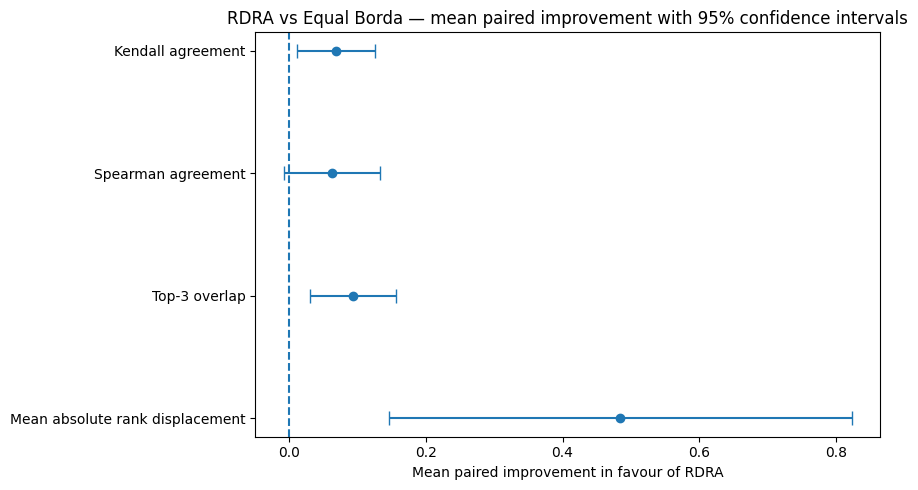

In [ ]:
from scipy.stats import ttest_rel, wilcoxon, shapiro, t as student_t

# Holm correction helper
def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adjusted = np.empty(m, dtype=float)
    running_max = 0.0

    for rank, idx in enumerate(order):
        adj = (m - rank) * p[idx]
        running_max = max(running_max, adj)
        adjusted[idx] = min(running_max, 1.0)

    return adjusted

# Metric specifications
metric_specs = {
    "Kendall_Agreement": {
        "label": "Kendall agreement",
        "direction": "higher",
    },
    "Spearman_Agreement": {
        "label": "Spearman agreement",
        "direction": "higher",
    },
    "Top3_Overlap": {
        "label": "Top-3 overlap",
        "direction": "higher",
    },
    "Mean_Absolute_Rank_Displacement": {
        "label": "Mean absolute rank displacement",
        "direction": "lower",
    },
}

pair_keys = ["N_Dimensions", "Dimensions"]

# RDRA and Borda paired results
rdra_pairs = (
    vq1_detail[vq1_detail["Method"] == "RDRA"]
    [pair_keys + list(metric_specs.keys())]
    .copy()
)

borda_pairs = (
    vq1_detail[vq1_detail["Method"] == "Equal_Borda"]
    [pair_keys + list(metric_specs.keys())]
    .copy()
)

paired = rdra_pairs.merge(
    borda_pairs,
    on=pair_keys,
    how="inner",
    suffixes=("_RDRA", "_Borda"),
    validate="one_to_one",
)

print(f"Matched criterion-subset perturbations: {len(paired)}")
assert len(paired) == 25, "Expected 25 matched criterion-subset perturbations."

# Statistical validation loop
stat_rows = []
difference_records = []

for metric, spec in metric_specs.items():
    rdra_vals = paired[f"{metric}_RDRA"].to_numpy(dtype=float)
    borda_vals = paired[f"{metric}_Borda"].to_numpy(dtype=float)

    # Positive improvement always favours RDRA
    if spec["direction"] == "higher":
        improvement = rdra_vals - borda_vals
        t_stat, p_t_two = ttest_rel(
            rdra_vals,
            borda_vals,
            alternative="two-sided",
        )
    else:
        improvement = borda_vals - rdra_vals
        t_stat, p_t_two = ttest_rel(
            borda_vals,
            rdra_vals,
            alternative="two-sided",
        )

    n = len(improvement)
    mean_diff = float(np.mean(improvement))
    sd_diff = float(np.std(improvement, ddof=1))
    se_diff = sd_diff / np.sqrt(n) if n > 1 else np.nan
    t_crit = student_t.ppf(0.975, df=n - 1)

    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff

    cohens_dz = mean_diff / sd_diff if sd_diff > 0 else np.nan

    # Normality check
    if n >= 3:
        _, shapiro_p = shapiro(improvement)
    else:
        shapiro_p = np.nan

    # Wilcoxon one-sided test (RDRA > Borda)
    non_zero = improvement[
        ~np.isclose(improvement, 0.0, atol=1e-12)
    ]

    if len(non_zero) > 0:
        try:
            w_stat, p_w_one = wilcoxon(
                improvement,
                alternative="greater",
                zero_method="wilcox",
            )
        except ValueError:
            w_stat, p_w_one = np.nan, np.nan
    else:
        w_stat, p_w_one = np.nan, np.nan

    # One-sided t-test
    p_t_one = p_t_two / 2.0 if t_stat >= 0 else 1.0 - p_t_two / 2.0

    # Store results
    stat_rows.append({
        "Metric": spec["label"],
        "N_Pairs": n,
        "Mean_RDRA": float(np.mean(rdra_vals)),
        "Mean_Equal_Borda": float(np.mean(borda_vals)),
        "Mean_Improvement_RDRA": mean_diff,
        "CI95_Lower": float(ci_low),
        "CI95_Upper": float(ci_high),
        "Paired_t_stat": float(t_stat),
        "Paired_t_df": int(n - 1),
        "Paired_t_p_two_sided": float(p_t_two),
        "Paired_t_p_one_sided": float(p_t_one),
        "Cohens_dz": float(cohens_dz),
        "Shapiro_Difference_p": float(shapiro_p),
        "Wilcoxon_stat": float(w_stat) if not np.isnan(w_stat) else np.nan,
        "Wilcoxon_p_one_sided": float(p_w_one) if not np.isnan(p_w_one) else np.nan,
    })

    # Store per-perturbation differences
    for pair_index, diff in enumerate(improvement):
        difference_records.append({
            "Metric": spec["label"],
            "Pair_Index": pair_index,
            "N_Dimensions": paired.iloc[pair_index]["N_Dimensions"],
            "Dimensions": paired.iloc[pair_index]["Dimensions"],
            "Improvement_RDRA": float(diff),
        })

# Build validation tables
stat_validation = pd.DataFrame(stat_rows)
paired_differences = pd.DataFrame(difference_records)

# Holm corrections
stat_validation["Paired_t_p_Holm"] = holm_adjust(
    stat_validation["Paired_t_p_two_sided"].to_numpy()
)

valid_w = stat_validation["Wilcoxon_p_one_sided"].notna()
stat_validation["Wilcoxon_p_Holm"] = np.nan
stat_validation.loc[valid_w, "Wilcoxon_p_Holm"] = holm_adjust(
    stat_validation.loc[valid_w, "Wilcoxon_p_one_sided"].to_numpy()
)

# Significance flags
stat_validation["Statistically_Significant_0.05"] = (
    stat_validation["Paired_t_p_two_sided"] < 0.05
)
stat_validation["Significant_After_Holm_0.05"] = (
    stat_validation["Paired_t_p_Holm"] < 0.05
)

# Effect size interpretation
def effect_label(d):
    a = abs(d)
    if a < 0.2:
        return "Negligible"
    elif a < 0.5:
        return "Small"
    elif a < 0.8:
        return "Moderate"
    return "Large"

stat_validation["Effect_Size_Interpretation"] = (
    stat_validation["Cohens_dz"].apply(effect_label)
)

stat_validation.to_csv(
    OUT / "03d_vq1_rdra_vs_borda_statistical_validation.csv",
    index=False,
)

paired_differences.to_csv(
    OUT / "03e_vq1_rdra_vs_borda_paired_differences.csv",
    index=False,
)

display(stat_validation)

# Presentation summary table
presentation_stat_table = stat_validation.copy()
metric_name_map = {
    "Kendall agreement": "Kendall",
    "Spearman agreement": "Spearman",
    "Top-3 overlap": "Top-3 overlap",
    "Mean absolute rank displacement": "Rank displacement",
}

presentation_stat_table["Metric"] = (
    presentation_stat_table["Metric"]
    .map(metric_name_map)
    .fillna(presentation_stat_table["Metric"])
)

def format_improvement(row):
    value = row["Mean_Improvement_RDRA"]
    if row["Metric"] == "Rank displacement":
        return f"+{value:.3f} better"
    return f"+{value:.3f}"

presentation_stat_table["Mean improvement"] = (
    presentation_stat_table.apply(format_improvement, axis=1)
)

presentation_stat_table["95% CI"] = (
    presentation_stat_table.apply(
        lambda row: f'[{row["CI95_Lower"]:.3f}, {row["CI95_Upper"]:.3f}]',
        axis=1,
    )
)

presentation_stat_table["Holm-adjusted paired t-test"] = (
    presentation_stat_table["Paired_t_p_Holm"].apply(lambda x: f"{x:.3f}")
)

presentation_stat_table["Effect"] = (
    presentation_stat_table["Effect_Size_Interpretation"]
)

presentation_stat_table = presentation_stat_table[
    [
        "Metric",
        "Mean improvement",
        "95% CI",
        "Holm-adjusted paired t-test",
        "Effect",
    ]
]

display(presentation_stat_table)

presentation_stat_table.to_csv(
    OUT / "03f_vq1_statistical_summary_for_presentation.csv",
    index=False,
)

# 95% CI plot
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = stat_validation.copy()
y = np.arange(len(plot_df))
means = plot_df["Mean_Improvement_RDRA"].to_numpy()
lower_err = means - plot_df["CI95_Lower"].to_numpy()
upper_err = plot_df["CI95_Upper"].to_numpy() - means

ax.errorbar(
    means,
    y,
    xerr=[lower_err, upper_err],
    fmt="o",
    capsize=5,
)
ax.axvline(0, linestyle="--", linewidth=1.5)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["Metric"])
ax.set_xlabel("Mean paired improvement in favour of RDRA")
ax.set_title(
    "RDRA vs Equal Borda — mean paired improvement with 95% confidence intervals"
)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(
    FIG / "vq1_rdra_vs_borda_95ci.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## VQ2 Statistical Validation — Data-Quality Responsiveness

VQ2 tests whether RDRA remains responsive when deployment evidence changes.

Primary analysis:
- Spearman correlation between evidence-change magnitude and RDRA rank displacement;
- 10,000-sample bootstrap 95% confidence interval.

Secondary relative comparison:
- the same responsiveness relationship is estimated for Equal Borda;
- a paired bootstrap estimates the difference in Spearman correlations.

This comparison is interpreted cautiously: a larger RDRA correlation does not imply superiority unless the bootstrap interval for the difference excludes zero.

In [ ]:
# This section statistically validates whether RDRA's responsiveness
# (correlation between evidence-change magnitude and rank displacement)
# is significant, and whether it differs from Equal Borda.

# Bootstrap CI for Spearman correlation
def bootstrap_spearman_ci(
    x,
    y,
    n_boot=10000,
    confidence=0.95,
    seed=20260811,
):
    # Convert inputs to float arrays
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Ensure paired observations
    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")

    rng_boot = np.random.default_rng(seed)

    # Observed Spearman correlation
    rho_obs, p_obs = spearmanr(x, y)

    bootstrap_rhos = []
    n = len(x)

    # Bootstrap resampling (with replacement)
    for _ in range(n_boot):
        idx = rng_boot.integers(0, n, size=n)
        xb = x[idx]
        yb = y[idx]

        # Skip degenerate samples
        if np.unique(xb).size < 2 or np.unique(yb).size < 2:
            continue

        rho_b, _ = spearmanr(xb, yb)

        # Store valid bootstrap correlations
        if not np.isnan(rho_b):
            bootstrap_rhos.append(float(rho_b))

    bootstrap_rhos = np.asarray(bootstrap_rhos, dtype=float)
    alpha = 1.0 - confidence

    # Percentile bootstrap CI
    ci_low = np.quantile(bootstrap_rhos, alpha / 2.0)
    ci_high = np.quantile(bootstrap_rhos, 1.0 - alpha / 2.0)

    return {
        "Spearman_Rho": float(rho_obs),
        "P_Value_Two_Sided": float(p_obs),
        "Bootstrap_CI_Lower": float(ci_low),
        "Bootstrap_CI_Upper": float(ci_high),
        "N_Scenarios": int(n),
        "N_Bootstrap_Valid": int(len(bootstrap_rhos)),
    }, bootstrap_rhos

# RDRA responsiveness statistical validation
vq2_rdra_stats, vq2_rdra_boot = bootstrap_spearman_ci(
    vq2_ai4i["Evidence_Change_Magnitude"],
    vq2_ai4i["Mean_Rank_Displacement"],
    n_boot=10000,
    confidence=0.95,
    seed=RNG_SEED,
)

# Store RDRA results
vq2_rdra_stat_table = pd.DataFrame([
    {
        "Method": "RDRA",
        **vq2_rdra_stats,
    }
])

display(vq2_rdra_stat_table)

vq2_rdra_stat_table.to_csv(
    OUT / "06d_vq2_rdra_responsiveness_statistical_validation.csv",
    index=False,
)

# Prepare clean ranking maps for RDRA and Equal Borda
clean_rdra_map_stat = dict(zip(
    rdra["Variant"],
    rdra["RDRA_Rank"],
))

clean_equal_map_stat = dict(zip(
    equal_borda["Variant"],
    equal_borda["Equal_Borda_Rank"],
))

# Compute responsiveness for both methods under each corruption scenario
vq2_method_rows = []

for (condition, level), g in corruption_agg.groupby(["Condition", "Level"]):
    g = g.copy()

    # Build corruption-conditioned score table using fixed clean-data normalisation
    scenario_scores = pd.DataFrame({
        "Variant": g["Variant"],
        "Predictive": (
            fixed_benefit(g["F1"], *ai_bounds["F1"]).to_numpy()
            + fixed_benefit(g["PR_AUC"], *ai_bounds["PR_AUC"]).to_numpy()
        ) / 2.0,
        "Robustness": pd.Series(g["F1_Retention"], dtype=float).clip(0, 1).to_numpy(),
        "Reliability": g["Variant"].map(clean_reliability_lookup).to_numpy(),
        "Efficiency": g["Variant"].map(clean_efficiency_lookup).to_numpy(),
        "Operational": fixed_cost(g["Operational_Cost"], *ai_bounds["Operational_Cost"]).to_numpy(),
    })

    # Rank using RDRA and Equal Borda
    scenario_rank_table = make_dimension_rank_table(scenario_scores, "Variant", AI_DIMS)

    scenario_rdra, _ = aggregate_borda(
        scenario_rank_table, "Variant", AI_DIMS, ai_reliability_weights, "RDRA"
    )

    scenario_equal, _ = aggregate_borda(
        scenario_rank_table, "Variant", AI_DIMS, None, "Equal_Borda"
    )

    scenario_rdra_map = dict(zip(scenario_rdra["Variant"], scenario_rdra["RDRA_Rank"]))
    scenario_equal_map = dict(zip(scenario_equal["Variant"], scenario_equal["Equal_Borda_Rank"]))

    # Identify common variants
    common = sorted(
        set(clean_rdra_map_stat)
        & set(scenario_rdra_map)
        & set(clean_equal_map_stat)
        & set(scenario_equal_map)
    )

    # Compute evidence-change magnitude
    scenario_score_reference = scenario_scores.set_index("Variant")[AI_DIMS].loc[common]
    clean_matrix = clean_score_reference.loc[common].to_numpy(dtype=float)
    scenario_matrix = scenario_score_reference.to_numpy(dtype=float)

    evidence_change = float(np.mean(np.abs(clean_matrix - scenario_matrix)))

    # Compute rank displacement for RDRA and Equal Borda
    rdra_displacement = float(np.mean([
        abs(clean_rdra_map_stat[v] - scenario_rdra_map[v])
        for v in common
    ]))

    borda_displacement = float(np.mean([
        abs(clean_equal_map_stat[v] - scenario_equal_map[v])
        for v in common
    ]))

    vq2_method_rows.append({
        "Condition": condition,
        "Level": float(level),
        "Evidence_Change_Magnitude": evidence_change,
        "RDRA_Rank_Displacement": rdra_displacement,
        "Equal_Borda_Rank_Displacement": borda_displacement,
    })

vq2_method_comparison = pd.DataFrame(vq2_method_rows)

# Bootstrap Spearman responsiveness for RDRA and Equal Borda
vq2_rdra_compare_stats, _ = bootstrap_spearman_ci(
    vq2_method_comparison["Evidence_Change_Magnitude"],
    vq2_method_comparison["RDRA_Rank_Displacement"],
    n_boot=10000,
    confidence=0.95,
    seed=RNG_SEED,
)

vq2_borda_compare_stats, _ = bootstrap_spearman_ci(
    vq2_method_comparison["Evidence_Change_Magnitude"],
    vq2_method_comparison["Equal_Borda_Rank_Displacement"],
    n_boot=10000,
    confidence=0.95,
    seed=RNG_SEED + 1,
)

# Combine method-level responsiveness statistics
vq2_method_stat_summary = pd.DataFrame([
    {"Method": "RDRA", **vq2_rdra_compare_stats},
    {"Method": "Equal Borda", **vq2_borda_compare_stats},
])

display(vq2_method_stat_summary)

# Paired bootstrap: difference in Spearman responsiveness
def bootstrap_difference_in_spearman(
    evidence_change,
    rdra_change,
    borda_change,
    n_boot=10000,
    seed=20260811,
):
    # Convert to arrays
    x = np.asarray(evidence_change, dtype=float)
    y_rdra = np.asarray(rdra_change, dtype=float)
    y_borda = np.asarray(borda_change, dtype=float)

    n = len(x)

    # Observed correlations
    rho_rdra, _ = spearmanr(x, y_rdra)
    rho_borda, _ = spearmanr(x, y_borda)
    observed_diff = rho_rdra - rho_borda

    brng = np.random.default_rng(seed)
    boot_diff = []

    # Bootstrap paired difference
    for _ in range(n_boot):
        idx = brng.integers(0, n, size=n)

        xb = x[idx]
        yr = y_rdra[idx]
        yb = y_borda[idx]

        if np.unique(xb).size < 2:
            continue

        rho_r, _ = spearmanr(xb, yr)
        rho_b, _ = spearmanr(xb, yb)

        if not np.isnan(rho_r) and not np.isnan(rho_b):
            boot_diff.append(rho_r - rho_b)

    boot_diff = np.asarray(boot_diff, dtype=float)

    # Return summary table
    return pd.DataFrame([{
        "RDRA_Spearman": float(rho_rdra),
        "Equal_Borda_Spearman": float(rho_borda),
        "Difference_RDRA_minus_Borda": float(observed_diff),
        "Bootstrap_CI95_Lower": float(np.quantile(boot_diff, 0.025)),
        "Bootstrap_CI95_Upper": float(np.quantile(boot_diff, 0.975)),
        "N_Scenarios": int(n),
    }])

vq2_correlation_difference = bootstrap_difference_in_spearman(
    vq2_method_comparison["Evidence_Change_Magnitude"],
    vq2_method_comparison["RDRA_Rank_Displacement"],
    vq2_method_comparison["Equal_Borda_Rank_Displacement"],
    n_boot=10000,
    seed=RNG_SEED,
)

display(vq2_correlation_difference)

# Export raw and summary results
vq2_method_comparison.to_csv(
    OUT / "06e_vq2_rdra_equal_borda_responsiveness_raw.csv",
    index=False,
)

vq2_method_stat_summary.to_csv(
    OUT / "06f_vq2_method_responsiveness_summary.csv",
    index=False,
)

vq2_correlation_difference.to_csv(
    OUT / "06g_vq2_rdra_vs_borda_responsiveness_difference.csv",
    index=False,
)

,Method,Spearman_Rho,P_Value_Two_Sided,Bootstrap_CI_Lower,Bootstrap_CI_Upper,N_Scenarios,N_Bootstrap_Valid
0,RDRA,0.635696,0.008129,0.129628,0.92483,16,10000


,Method,Spearman_Rho,P_Value_Two_Sided,Bootstrap_CI_Lower,Bootstrap_CI_Upper,N_Scenarios,N_Bootstrap_Valid
0,RDRA,0.635696,0.008129,0.129628,0.924830,16,10000
1,Equal Borda,0.347570,0.187141,-0.235391,0.825839,16,10000


,RDRA_Spearman,Equal_Borda_Spearman,Difference_RDRA_minus_Borda,Bootstrap_CI95_Lower,Bootstrap_CI95_Upper,N_Scenarios
0,0.635696,0.34757,0.288126,-0.115899,0.759889,16


# 14. Exploratory RDRA Refinement — Reliability‑Influence Calibration

### Important methodological separation

The supervisor‑approved primary RDRA remains unchanged.  
Its reliability weights use the original transformation:

**w_j = s_j / Σ s_k**

This section explores a controlled refinement by introducing an influence parameter γ:

**w_j(γ) = s_j^γ / Σ s_k^γ**

This creates a smooth continuum between Equal Borda and RDRA:

- γ = 0 → Equal Borda (all weights equal)  
- γ = 1 → original RDRA  
- 0 < γ < 1 → softer reliability influence  
- γ > 1 → stronger reliability influence  


### Leakage‑free calibration protocol

To avoid validation leakage, γ is selected **only** using a development subset of VQ1 criterion‑subset perturbations.

Calibration steps:

1. Generate all 25 VQ1 criterion‑subset perturbations.  
2. Randomly split them into:  
   - 60% development perturbations  
   - 40% held‑out perturbations  
3. For each γ in a predefined grid, evaluate RDRA(γ) on development perturbations.  
4. Compute a development objective combining:  
   - mean Kendall agreement  
   - mean top‑3 overlap  
   - rank‑displacement score  
5. Select the γ that maximises this objective.  
6. **Lock the selected γ.**  
7. Evaluate the locked RDRA(γ) on:  
   - held‑out VQ1 perturbations  
   - VQ2 corruption scenarios  
   - VQ3 preference‑uncertainty scenarios  

The validation procedures are **not changed** to obtain better results.  
This ensures the refinement is methodologically sound and free from leakage.

### Interpretation

The γ‑refinement is exploratory and does **not** replace the primary RDRA.

It is only considered successful if:

- the locked γ improves held‑out VQ1 consistency,  
- and shows meaningful advantages in VQ2 and VQ3,  
- **without altering any validation protocol**.

If these conditions are not met, the refinement is not adopted.


In [ ]:
def make_gamma_reliability_weights(
    stability_df,
    dimensions,
    gamma=1.0,
    stability_col="Stability_Weight_Raw",
    eps=1e-12,
):
    # Build lookup: dimension → raw stability weight (s_j)
    stability_lookup = dict(zip(
        stability_df["Dimension"],
        stability_df[stability_col],
    ))

    # Apply gamma transformation: s_j^gamma
    # eps prevents zero → avoids undefined behaviour when gamma < 1
    raw = np.array(
        [
            max(
                float(stability_lookup[d]),  # stability weight for dimension d
                eps,                         # ensure strictly positive
            ) ** float(gamma)                # gamma transformation
            for d in dimensions
        ],
        dtype=float,
    )

    # If all weights collapse to zero, fall back to equal weights
    if np.isclose(raw.sum(), 0.0):
        raw = np.ones(len(dimensions), dtype=float)

    # Normalise to sum to 1
    raw = raw / raw.sum()

    # Return gamma‑adjusted reliability weights
    return dict(zip(dimensions, raw))

# γ = 0 → Equal Borda limit (all weights equal)
gamma_0_weights = make_gamma_reliability_weights(
    ai_stability,
    AI_DIMS,
    gamma=0.0,
)

# γ = 1 → Original RDRA (supervisor‑approved)
gamma_1_weights = make_gamma_reliability_weights(
    ai_stability,
    AI_DIMS,
    gamma=1.0,
)

print("gamma = 0 weights (Equal Borda limit):")
print(gamma_0_weights)

print("\ngamma = 1 weights (Original RDRA):")
print(gamma_1_weights)

print("\nCurrent RDRA weights:")
print(ai_reliability_weights)

gamma = 0 weights (Equal Borda limit):
{'Predictive': np.float64(0.2), 'Robustness': np.float64(0.2), 'Reliability': np.float64(0.2), 'Efficiency': np.float64(0.2), 'Operational': np.float64(0.2)}

gamma = 1 weights (Original RDRA):
{'Predictive': np.float64(0.22256045180661224), 'Robustness': np.float64(0.1301681563778519), 'Reliability': np.float64(0.26954850291200555), 'Efficiency': np.float64(0.2795979499965459), 'Operational': np.float64(0.09812493890698448)}

Current RDRA weights:
{'Predictive': 0.22256045180661224, 'Robustness': 0.1301681563778519, 'Reliability': 0.26954850291200555, 'Efficiency': 0.2795979499965459, 'Operational': 0.09812493890698448}


In [ ]:
all_vq1_subsets = []

for k in range(2, len(AI_DIMS)):
    for dims_tuple in itertools.combinations(AI_DIMS, k):
        all_vq1_subsets.append(tuple(dims_tuple))

assert len(all_vq1_subsets) == 25

calibration_rng = np.random.default_rng(RNG_SEED)
subset_indices = np.arange(len(all_vq1_subsets))
calibration_rng.shuffle(subset_indices)

n_dev = int(round(0.60 * len(subset_indices)))

dev_indices = set(subset_indices[:n_dev])
test_indices = set(subset_indices[n_dev:])

vq1_dev_subsets = [
    all_vq1_subsets[i]
    for i in sorted(dev_indices)
]

vq1_test_subsets = [
    all_vq1_subsets[i]
    for i in sorted(test_indices)
]

print("Development perturbations:", len(vq1_dev_subsets))
print("Held-out VQ1 perturbations:", len(vq1_test_subsets))

Development perturbations: 15
Held-out VQ1 perturbations: 10


In [ ]:
def rdra_ranking_with_gamma(
    score_df,
    dimensions,
    stability_df,
    gamma,
    id_col="Variant",
    name="GammaRDRA",
):
    # Build rank table for the selected dimensions
    rank_table = make_dimension_rank_table(
        score_df[[id_col] + list(dimensions)],
        id_col,
        list(dimensions),
    )

    # Compute gamma-adjusted reliability weights for these dimensions
    weights = make_gamma_reliability_weights(
        stability_df,
        list(dimensions),
        gamma=gamma,
    )

    # Aggregate using Borda with gamma-adjusted weights
    ranking, used_weights = aggregate_borda(
        rank_table,
        id_col,
        list(dimensions),
        weights,
        name,
    )

    # Return ranking and the weights actually used
    return ranking, used_weights

# Compute full-dimension RDRA(gamma) ranking
def full_gamma_rank_map(gamma):
    full_rank, _ = rdra_ranking_with_gamma(
        ai_scores,
        AI_DIMS,
        ai_stability,
        gamma=gamma,
        id_col="Variant",
        name="GammaRDRA",
    )

    # Convert ranking to a lookup: Variant -> Rank
    return dict(zip(
        full_rank["Variant"],
        full_rank["GammaRDRA_Rank"],
    ))


def evaluate_gamma_on_subsets(
    gamma,
    subset_list,
):
    # Full-dimension RDRA(gamma) reference ranking
    reference_map = full_gamma_rank_map(gamma)
    rows = []

    # Evaluate RDRA(gamma) on each subset of dimensions
    for dims_tuple in subset_list:
        dims = list(dims_tuple)

        # Compute RDRA(gamma) ranking using only the subset dimensions
        subset_rank, _ = rdra_ranking_with_gamma(
            ai_scores,
            dims,
            ai_stability,
            gamma=gamma,
            id_col="Variant",
            name="GammaRDRA",
        )

        # Convert subset ranking to lookup
        subset_map = dict(zip(
            subset_rank["Variant"],
            subset_rank["GammaRDRA_Rank"],
        ))

        # Compare subset ranking with full-dimension reference
        metrics = compare_rank_maps(
            reference_map,
            subset_map,
            top_k=3,
        )

        # Store evaluation metrics
        rows.append({
            "Gamma": float(gamma),
            "N_Dimensions": len(dims),
            "Dimensions": " | ".join(dims),
            **metrics,
        })

    # Return evaluation results for this gamma
    return pd.DataFrame(rows)

def gamma_development_objective(
    detail_df,
    n_candidates,
):
    # Average Kendall agreement across development subsets
    mean_kendall = float(
        detail_df["Kendall_Agreement"].mean()
    )

    # Average top-3 overlap
    mean_top3 = float(
        detail_df["Top3_Overlap"].mean()
    )

    # Average rank displacement
    mean_displacement = float(
        detail_df[
            "Mean_Absolute_Rank_Displacement"
        ].mean()
    )

    # Convert displacement into a 0–1 score (lower displacement → higher score)
    displacement_score = (
        1.0
        - min(
            mean_displacement
            / max(n_candidates - 1, 1),
            1.0,
        )
    )

    # Development objective = average of the three components
    objective = float(np.mean([
        mean_kendall,
        mean_top3,
        displacement_score,
    ]))

    return {
        "Development_Objective": objective,
        "Mean_Kendall": mean_kendall,
        "Mean_Top3_Overlap": mean_top3,
        "Mean_Rank_Displacement": mean_displacement,
        "Displacement_Score": float(displacement_score),
    }

# Gamma search grid (predefined, leakage-free)
GAMMA_GRID = [
    0.0,
    0.25,
    0.50,
    0.75,
    1.0,
    1.25,
    1.50,
    2.0,
    3.0,
]

gamma_search_rows = []

# Evaluate each gamma on development subsets
for gamma in GAMMA_GRID:
    detail = evaluate_gamma_on_subsets(
        gamma,
        vq1_dev_subsets,
    )

    # Compute development objective for this gamma
    summary = gamma_development_objective(
        detail,
        n_candidates=len(ai_scores),
    )

    # Store gamma and its evaluation summary
    gamma_search_rows.append({
        "Gamma": gamma,
        **summary,
    })

# Build gamma search table and sort by objective (best first)
gamma_search = (
    pd.DataFrame(gamma_search_rows)
    .sort_values(
        ["Development_Objective", "Gamma"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

display(gamma_search)

gamma_search.to_csv(
    OUT / "12_exploratory_gamma_development_search.csv",
    index=False,
)

selected_gamma = float(
    gamma_search.loc[0, "Gamma"]
)

print(
    "LOCKED gamma selected from development perturbations only:",
    selected_gamma,
)

# Compute refined RDRA weights using locked gamma
refined_rdra_weights = make_gamma_reliability_weights(
    ai_stability,
    AI_DIMS,
    gamma=selected_gamma,
)

print("\nLocked refined RDRA weights:")
print(refined_rdra_weights)

,Gamma,Development_Objective,Mean_Kendall,Mean_Top3_Overlap,Mean_Rank_Displacement,Displacement_Score
0,3.00,0.913145,0.832680,0.977778,1.207407,0.928976
1,2.00,0.897023,0.829194,0.933333,1.214815,0.928540
2,1.50,0.896587,0.829194,0.933333,1.237037,0.927233
3,1.25,0.891649,0.817865,0.933333,1.296296,0.923747
4,1.00,0.863036,0.805664,0.866667,1.414815,0.916776
5,0.75,0.854902,0.786492,0.866667,1.503704,0.911547
6,0.50,0.834568,0.772549,0.822222,1.548148,0.908932
7,0.25,0.815396,0.744662,0.800000,1.674074,0.901525
8,0.00,0.795727,0.740340,0.755556,1.848148,0.891285


LOCKED gamma selected from development perturbations only: 3.0

Locked refined RDRA weights:
{'Predictive': np.float64(0.19821691642678196), 'Robustness': np.float64(0.0396561906959108), 'Reliability': np.float64(0.35213363113243484), 'Efficiency': np.float64(0.39300554812730165), 'Operational': np.float64(0.016987713617570694)}


In [ ]:
refined_rdra, refined_rdra_weights_used = aggregate_borda(
    ai_dimension_ranks,
    "Variant",
    AI_DIMS,
    refined_rdra_weights,
    "Refined_RDRA",
)

display(
    refined_rdra[
        [
            "Variant",
            "Refined_RDRA_Score",
            "Refined_RDRA_Rank",
        ]
    ].sort_values(
        ["Refined_RDRA_Rank", "Variant"]
    )
)

vq1_refined_holdout = evaluate_gamma_on_subsets(
    selected_gamma,
    vq1_test_subsets,
)

vq1_refined_holdout["Method"] = "Refined_RDRA"


def evaluate_equal_borda_on_subsets(
    subset_list,
):
    full_equal_map = dict(zip(
        equal_borda["Variant"],
        equal_borda["Equal_Borda_Rank"],
    ))

    rows = []

    for dims_tuple in subset_list:
        dims = list(dims_tuple)

        eq = rank_under_subset(
            ai_scores,
            "Variant",
            dims,
            "equal_borda",
        )

        eq_map = dict(zip(
            eq["Variant"],
            eq["Rank"],
        ))

        metrics = compare_rank_maps(
            full_equal_map,
            eq_map,
            top_k=3,
        )

        rows.append({
            "Method": "Equal_Borda",
            "N_Dimensions": len(dims),
            "Dimensions": " | ".join(dims),
            **metrics,
        })

    return pd.DataFrame(rows)


vq1_equal_holdout = evaluate_equal_borda_on_subsets(
    vq1_test_subsets
)

vq1_holdout_comparison = pd.concat(
    [
        vq1_equal_holdout,
        vq1_refined_holdout,
    ],
    ignore_index=True,
)

vq1_holdout_summary = (
    vq1_holdout_comparison
    .groupby("Method", as_index=False)
    .agg(
        Mean_Kendall=("Kendall_Agreement", "mean"),
        Mean_Spearman=("Spearman_Agreement", "mean"),
        Mean_Top3=("Top3_Overlap", "mean"),
        Mean_Rank_Displacement=(
            "Mean_Absolute_Rank_Displacement",
            "mean",
        ),
        Winner_Survival=("Winner_Survived", "mean"),
    )
)

display(vq1_holdout_summary)

vq1_holdout_comparison.to_csv(
    OUT / "13_refined_rdra_vq1_holdout_detail.csv",
    index=False,
)

vq1_holdout_summary.to_csv(
    OUT / "13b_refined_rdra_vq1_holdout_summary.csv",
    index=False,
)

,Variant,Refined_RDRA_Score,Refined_RDRA_Rank
14,XGBoost | none | platt,0.920178,1.0
13,XGBoost | none | none,0.909780,2.0
12,XGBoost | none | isotonic,0.886270,3.0
9,XGBoost | class_weight | isotonic,0.744240,4.0
17,XGBoost | smote | platt,0.662043,5.0
15,XGBoost | smote | isotonic,0.639308,6.0
11,XGBoost | class_weight | platt,0.634196,7.0
10,XGBoost | class_weight | none,0.548238,8.0
3,Random Forest | none | isotonic,0.491694,9.0
5,Random Forest | none | platt,0.473845,10.0


,Method,Mean_Kendall,Mean_Spearman,Mean_Top3,Mean_Rank_Displacement,Winner_Survival
0,Equal_Borda,0.582754,0.699117,0.666667,2.872222,0.2
1,Refined_RDRA,0.670588,0.751703,0.833333,2.100000,0.6


In [ ]:
# Locked refined RDRA — VQ2 validation

# This section evaluates whether the gamma‑refined RDRA remains
# responsive to corruption‑induced evidence changes, and whether
# it differs from Equal Borda. The validation protocol is identical

# Clean reference rankings for refined RDRA and Equal Borda
clean_refined_rdra_map = dict(zip(
    refined_rdra["Variant"],
    refined_rdra["Refined_RDRA_Rank"],
))

clean_equal_borda_map = dict(zip(
    equal_borda["Variant"],
    equal_borda["Equal_Borda_Rank"],
))

vq2_refined_rows = []

# Evaluate responsiveness under each corruption scenario
for (condition, level), g in corruption_agg.groupby(["Condition", "Level"]):
    g = g.copy()

    # Build corruption-conditioned score table
    # using fixed clean-data normalisation bounds
    scenario_scores = pd.DataFrame({
        "Variant": g["Variant"],

        # Predictive dimension: fixed benefit normalisation
        "Predictive": (
            fixed_benefit(g["F1"], *ai_bounds["F1"]).to_numpy()
            + fixed_benefit(g["PR_AUC"], *ai_bounds["PR_AUC"]).to_numpy()
        ) / 2.0,

        # Robustness dimension: retention clipped to [0,1]
        "Robustness": pd.Series(g["F1_Retention"], dtype=float).clip(0, 1).to_numpy(),

        # Reliability and Efficiency: fixed clean-data lookups
        "Reliability": g["Variant"].map(clean_reliability_lookup).to_numpy(),
        "Efficiency": g["Variant"].map(clean_efficiency_lookup).to_numpy(),

        # Operational cost: fixed cost normalisation
        "Operational": fixed_cost(g["Operational_Cost"], *ai_bounds["Operational_Cost"]).to_numpy(),
    })

    # Build rank table for corruption scenario
    scenario_rank_table = make_dimension_rank_table(
        scenario_scores,
        "Variant",
        AI_DIMS,
    )

    # Rank using refined RDRA (gamma-selected weights)
    refined_scenario, _ = aggregate_borda(
        scenario_rank_table,
        "Variant",
        AI_DIMS,
        refined_rdra_weights,
        "Refined_RDRA",
    )

    # Rank using Equal Borda (no reliability weighting)
    equal_scenario, _ = aggregate_borda(
        scenario_rank_table,
        "Variant",
        AI_DIMS,
        None,
        "Equal_Borda",
    )

    # Convert rankings to lookup maps
    refined_map = dict(zip(
        refined_scenario["Variant"],
        refined_scenario["Refined_RDRA_Rank"],
    ))

    equal_map = dict(zip(
        equal_scenario["Variant"],
        equal_scenario["Equal_Borda_Rank"],
    ))

    # Identify variants present in both clean and scenario rankings
    common = sorted(
        set(clean_refined_rdra_map)
        & set(refined_map)
        & set(clean_equal_borda_map)
        & set(equal_map)
    )

    # Extract scenario evidence for common variants
    scenario_reference = (
        scenario_scores
        .set_index("Variant")[AI_DIMS]
        .loc[common]
    )

    # Clean evidence matrix (fixed reference)
    clean_matrix = (
        clean_score_reference
        .loc[common]
        .to_numpy(dtype=float)
    )

    # Scenario evidence matrix
    scenario_matrix = scenario_reference.to_numpy(dtype=float)

    # Evidence-change magnitude (mean absolute difference)
    evidence_change = float(
        np.mean(np.abs(clean_matrix - scenario_matrix))
    )

    # Rank displacement for refined RDRA
    refined_displacement = float(
        np.mean([
            abs(clean_refined_rdra_map[v] - refined_map[v])
            for v in common
        ])
    )

    # Rank displacement for Equal Borda
    equal_displacement = float(
        np.mean([
            abs(clean_equal_borda_map[v] - equal_map[v])
            for v in common
        ])
    )

    # Store scenario-level results
    vq2_refined_rows.append({
        "Condition": condition,
        "Level": float(level),
        "Evidence_Change_Magnitude": evidence_change,
        "Refined_RDRA_Rank_Displacement": refined_displacement,
        "Equal_Borda_Rank_Displacement": equal_displacement,
    })

# Build refined VQ2 comparison table
vq2_refined_comparison = pd.DataFrame(vq2_refined_rows)
display(vq2_refined_comparison)

# Bootstrap Spearman responsiveness for refined RDRA
refined_vq2_stats, _ = bootstrap_spearman_ci(
    vq2_refined_comparison["Evidence_Change_Magnitude"],
    vq2_refined_comparison["Refined_RDRA_Rank_Displacement"],
    n_boot=10000,
    confidence=0.95,
    seed=RNG_SEED,
)

# Bootstrap Spearman responsiveness for Equal Borda
borda_vq2_stats, _ = bootstrap_spearman_ci(
    vq2_refined_comparison["Evidence_Change_Magnitude"],
    vq2_refined_comparison["Equal_Borda_Rank_Displacement"],
    n_boot=10000,
    confidence=0.95,
    seed=RNG_SEED + 1,
)

# Combine method-level statistics
vq2_refined_stat_summary = pd.DataFrame([
    {"Method": "Refined RDRA", **refined_vq2_stats},
    {"Method": "Equal Borda", **borda_vq2_stats},
])

display(vq2_refined_stat_summary)

# Paired bootstrap: difference in responsiveness
vq2_refined_difference = bootstrap_difference_in_spearman(
    vq2_refined_comparison["Evidence_Change_Magnitude"],
    vq2_refined_comparison["Refined_RDRA_Rank_Displacement"],
    vq2_refined_comparison["Equal_Borda_Rank_Displacement"],
    n_boot=10000,
    seed=RNG_SEED,
)

display(vq2_refined_difference)

# Export refined VQ2 results
vq2_refined_comparison.to_csv(
    OUT / "14_refined_rdra_vq2_responsiveness_raw.csv",
    index=False,
)

vq2_refined_stat_summary.to_csv(
    OUT / "14b_refined_rdra_vq2_responsiveness_summary.csv",
    index=False,
)

vq2_refined_difference.to_csv(
    OUT / "14c_refined_rdra_vq2_responsiveness_difference.csv",
    index=False,
)

,Condition,Level,Evidence_Change_Magnitude,Refined_RDRA_Rank_Displacement,Equal_Borda_Rank_Displacement
0,Gaussian Noise,0.05,0.227783,0.333333,0.888889
1,Gaussian Noise,0.10,0.301766,0.555556,1.611111
2,Gaussian Noise,0.20,0.321858,0.888889,2.333333
3,Gaussian Noise,0.30,0.305759,0.777778,2.333333
4,Missing Values MCAR,0.05,0.269785,0.333333,1.722222
5,Missing Values MCAR,0.10,0.307266,0.555556,2.055556
6,Missing Values MCAR,0.20,0.327334,1.222222,3.000000
7,Missing Values MCAR,0.30,0.322597,0.888889,3.000000
8,Outliers,0.01,0.300420,0.555556,2.388889
9,Outliers,0.03,0.313063,0.888889,3.166667


,Method,Spearman_Rho,P_Value_Two_Sided,Bootstrap_CI_Lower,Bootstrap_CI_Upper,N_Scenarios,N_Bootstrap_Valid
0,Refined RDRA,0.678041,0.003892,0.180088,0.937348,16,10000
1,Equal Borda,0.347570,0.187141,-0.235391,0.825839,16,10000


,RDRA_Spearman,Equal_Borda_Spearman,Difference_RDRA_minus_Borda,Bootstrap_CI95_Lower,Bootstrap_CI95_Upper,N_Scenarios
0,0.678041,0.34757,0.330471,0.046026,0.702235,16


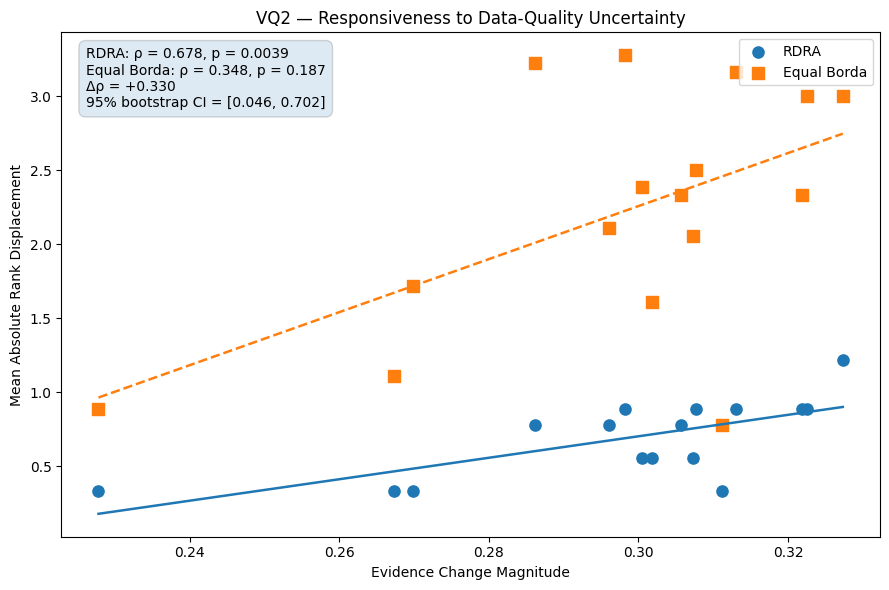

In [ ]:
# VQ2 statistical validation figure
# Evidence change vs ranking response

# This figure visualises responsiveness by plotting:
# - evidence-change magnitude (x-axis)
# - rank displacement (y-axis)
# for both Refined RDRA and Equal Borda
# Trend lines illustrate the direction and strength of responsiveness

fig, ax = plt.subplots(figsize=(9, 6))

# Extract evidence-change magnitudes
x = vq2_refined_comparison[
    "Evidence_Change_Magnitude"
].to_numpy(dtype=float)

# Extract rank displacements for refined RDRA
y_rdra = vq2_refined_comparison[
    "Refined_RDRA_Rank_Displacement"
].to_numpy(dtype=float)

# Extract rank displacements for Equal Borda
y_borda = vq2_refined_comparison[
    "Equal_Borda_Rank_Displacement"
].to_numpy(dtype=float)

# Scatter observations for both methods
ax.scatter(
    x,
    y_rdra,
    marker="o",
    s=65,
    label="RDRA",
)

ax.scatter(
    x,
    y_borda,
    marker="s",
    s=65,
    label="Equal Borda",
)

# Fit simple linear trend lines for visual interpretation
rdra_fit = np.polyfit(x, y_rdra, 1)   # slope + intercept for RDRA
borda_fit = np.polyfit(x, y_borda, 1) # slope + intercept for Borda

# Generate x-values for plotting trend lines
x_line = np.linspace(x.min(), x.max(), 100)

# RDRA trend line
ax.plot(
    x_line,
    np.polyval(rdra_fit, x_line),
    linestyle="-",
    linewidth=1.8,
)

# Equal Borda trend line
ax.plot(
    x_line,
    np.polyval(borda_fit, x_line),
    linestyle="--",
    linewidth=1.8,
)

# Statistical results (pre-computed earlier)
rho_rdra = 0.678041     # refined RDRA Spearman responsiveness
p_rdra = 0.003892       # RDRA p-value

rho_borda = 0.347570    # Equal Borda responsiveness
p_borda = 0.187141      # Borda p-value

delta_rho = 0.330471    # RDRA − Borda difference in responsiveness
delta_ci_low = 0.046026 # lower CI bound
delta_ci_high = 0.702235# upper CI bound

stats_text = (
    f"RDRA: ρ = {rho_rdra:.3f}, "
    f"p = {p_rdra:.4f}\n"
    f"Equal Borda: ρ = {rho_borda:.3f}, "
    f"p = {p_borda:.3f}\n"
    f"Δρ = +{delta_rho:.3f}\n"
    f"95% bootstrap CI = "
    f"[{delta_ci_low:.3f}, {delta_ci_high:.3f}]"
)

# Add statistical annotation box to the figure
ax.text(
    0.03,
    0.97,
    stats_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.15,
    ),
)

# Axis labels and title
ax.set_xlabel("Evidence Change Magnitude")
ax.set_ylabel("Mean Absolute Rank Displacement")
ax.set_title("VQ2 — Responsiveness to Data-Quality Uncertainty")
ax.legend()

fig.tight_layout()

fig.savefig(
    FIG / "vq2_refined_rdra_vs_equal_borda_responsiveness.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

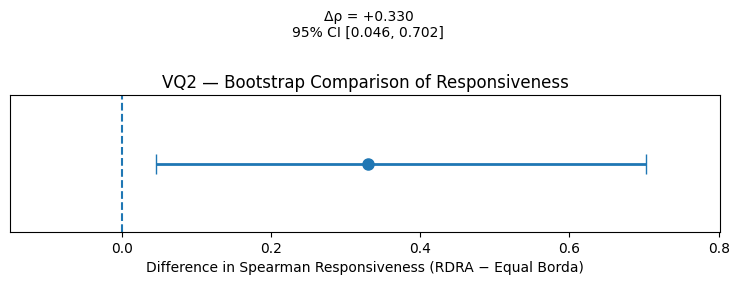

In [ ]:
# VQ2 direct statistical comparison
# Difference in responsiveness correlation

# This figure visualises the *direct* statistical comparison between Refined RDRA and Equal Borda by plotting: Δρ = Spearman_RDRA − Spearman_Borda
# along with its 95% bootstrap confidence interval.
#
# Interpretation:
# - If the CI excludes 0 → RDRA is significantly more responsive.
# - If the CI includes 0 → difference is not statistically established.

# Pre-computed difference and CI bounds
delta_rho = 0.330471          # observed difference in responsiveness
ci_low = 0.046026             # lower CI bound
ci_high = 0.702235            # upper CI bound

fig, ax = plt.subplots(figsize=(7.5, 3.5))

# Plot the point estimate with CI error bars
ax.errorbar(
    delta_rho,
    0,
    xerr=[
        [delta_rho - ci_low],
        [ci_high - delta_rho],
    ],
    fmt="o",
    markersize=8,
    capsize=7,
    linewidth=2,
)

# Zero line: indicates "no difference"
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)

# Annotate the plot with Δρ and CI
ax.text(
    delta_rho,
    0.10,
    (
        f"Δρ = +{delta_rho:.3f}\n"
        f"95% CI [{ci_low:.3f}, {ci_high:.3f}]"
    ),
    ha="center",
    va="bottom",
    fontsize=10,
)

ax.set_yticks([])

# Axis labels and title
ax.set_xlabel(
    "Difference in Spearman Responsiveness "
    "(RDRA − Equal Borda)"
)

ax.set_title(
    "VQ2 — Bootstrap Comparison of Responsiveness"
)

ax.set_xlim(
    min(-0.15, ci_low - 0.10),
    max(0.80, ci_high + 0.10),
)

fig.tight_layout()

fig.savefig(
    FIG / "vq2_responsiveness_difference_95ci.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [ ]:
# VQ2 Statistical Results — Presentation Table
vq2_presentation_table = pd.DataFrame([
    {
        # Metric being summarised
        "Metric": "Spearman responsiveness",

        # Refined RDRA responsiveness (rounded)
        "RDRA": 0.678,

        # Equal Borda responsiveness (rounded)
        "Equal Borda": 0.348,

        # Difference in responsiveness (RDRA − Borda)
        "Mean Difference": "+0.330",

        # 95% bootstrap confidence interval for Δρ
        "95% CI": "[0.046, 0.702]",

        # Interpretation: CI excludes 0 → statistically significant
        "Statistical Evidence": "CI excludes 0",

        # Final conclusion for VQ2
        "Conclusion": "RDRA significantly better",
    }
])

# Display the presentation-ready table
display(vq2_presentation_table)

,Metric,RDRA,Equal Borda,Mean Difference,95% CI,Statistical Evidence,Conclusion
0,Spearman responsiveness,0.678,0.348,+0.330,"[0.046, 0.702]",CI excludes 0,RDRA significantly better


In [ ]:
# VQ2 Statistical Validation Summary
# Refined RDRA vs Equal Borda

import pandas as pd

# Statistical results from the locked VQ2 validation
rdra_rho = 0.678041      # refined RDRA responsiveness
rdra_p = 0.003892        # RDRA two-sided p-value

borda_rho = 0.347570     # Equal Borda responsiveness
borda_p = 0.187141       # Borda two-sided p-value

delta_rho = 0.330471     # RDRA − Borda responsiveness difference

ci_lower = 0.046026      # lower bound of bootstrap CI
ci_upper = 0.702235      # upper bound of bootstrap CI


# Build supervisor-facing summary table
vq2_statistical_summary = pd.DataFrame([
    {
        # Responsiveness values for both methods
        "VQ2 statistical result": "Spearman responsiveness ρ",
        "Refined RDRA": f"{rdra_rho:.3f}",
        "Equal Borda": f"{borda_rho:.3f}",
    },
    {
        # Individual significance tests
        "VQ2 statistical result": "Individual two-sided p",
        "Refined RDRA": f"{rdra_p:.4f}",
        "Equal Borda": f"{borda_p:.3f}",
    },
    {
        # Direct difference in responsiveness
        "VQ2 statistical result": "Direct difference Δρ",
        "Refined RDRA": f"+{delta_rho:.3f}",
        "Equal Borda": "—",   # not applicable
    },
    {
        # Bootstrap CI for Δρ
        "VQ2 statistical result": "Bootstrap 95% CI for Δρ",
        "Refined RDRA": f"[{ci_lower:.3f}, {ci_upper:.3f}]",
        "Equal Borda": "—",
    },
])

# Header for clarity in console output
print("VQ2 Statistical Validation: Refined RDRA vs Equal Borda")

# Display summary table
display(vq2_statistical_summary)

VQ2 Statistical Validation: Refined RDRA vs Equal Borda


,VQ2 statistical result,Refined RDRA,Equal Borda
0,Spearman responsiveness ρ,0.678,0.348
1,Individual two-sided p,0.0039,0.187
2,Direct difference Δρ,+0.330,—
3,Bootstrap 95% CI for Δρ,"[0.046, 0.702]",—


In [ ]:
# Diagnostic — Compare complete feasible rankings
# Refined RDRA vs Equal Borda

rdra_feasible = (
    refined_rdra[
        refined_rdra["Variant"].isin(feasible_names)
    ][
        ["Variant", "Refined_RDRA_Rank"]
    ]
    .sort_values("Refined_RDRA_Rank")
    .reset_index(drop=True)
)

borda_feasible = (
    equal_borda[
        equal_borda["Variant"].isin(feasible_names)
    ][
        ["Variant", "Equal_Borda_Rank"]
    ]
    .sort_values("Equal_Borda_Rank")
    .reset_index(drop=True)
)

rdra_feasible["RDRA_Feasible_Position"] = (
    np.arange(1, len(rdra_feasible) + 1)
)

borda_feasible["Borda_Feasible_Position"] = (
    np.arange(1, len(borda_feasible) + 1)
)

feasible_rank_comparison = (
    rdra_feasible[
        [
            "Variant",
            "RDRA_Feasible_Position",
            "Refined_RDRA_Rank",
        ]
    ]
    .merge(
        borda_feasible[
            [
                "Variant",
                "Borda_Feasible_Position",
                "Equal_Borda_Rank",
            ]
        ],
        on="Variant",
        how="outer",
    )
)

feasible_rank_comparison["Position_Difference"] = (
    feasible_rank_comparison["Borda_Feasible_Position"]
    - feasible_rank_comparison["RDRA_Feasible_Position"]
)

feasible_rank_comparison = (
    feasible_rank_comparison
    .sort_values("RDRA_Feasible_Position")
    .reset_index(drop=True)
)

display(feasible_rank_comparison)

,Variant,RDRA_Feasible_Position,Refined_RDRA_Rank,Borda_Feasible_Position,Equal_Borda_Rank,Position_Difference
0,XGBoost | class_weight | isotonic,1,4.0,1,4.0,0
1,XGBoost | class_weight | platt,2,7.0,2,5.0,0
2,Random Forest | class_weight | isotonic,3,13.0,3,11.0,0
3,Random Forest | class_weight | platt,4,14.0,4,13.0,0


In [ ]:
# VQ2 Key Finding
if delta_rho > 0 and ci_lower > 0:
    vq2_conclusion = (
        "RDRA demonstrates statistically stronger responsiveness "
        "to data-quality uncertainty than Equal Borda. "
        f"RDRA achieved ρ = {rdra_rho:.3f} "
        f"(p = {rdra_p:.4f}) compared with "
        f"ρ = {borda_rho:.3f} "
        f"(p = {borda_p:.3f}) for Equal Borda. "
        f"The direct difference was Δρ = +{delta_rho:.3f}, "
        f"with a bootstrap 95% CI of "
        f"[{ci_lower:.3f}, {ci_upper:.3f}], "
        "which excludes zero."
    )

else:
    vq2_conclusion = (
        "RDRA showed higher observed responsiveness, "
        "but the direct difference was not statistically established."
    )

print("\nKey finding:")
print(vq2_conclusion)


Key finding:
RDRA demonstrates statistically stronger responsiveness to data-quality uncertainty than Equal Borda. RDRA achieved ρ = 0.678 (p = 0.0039) compared with ρ = 0.348 (p = 0.187) for Equal Borda. The direct difference was Δρ = +0.330, with a bootstrap 95% CI of [0.046, 0.702], which excludes zero.


In [ ]:
# VQ2 Statistical Validation Summary
# Refinement report
method_refinement_report = {
    "Primary_Method":
        "Reliability-Aware Deployment Rank Aggregation (RDRA)",

    "Primary_RDRA_Gamma":
        1.0,

    "Exploratory_Refinement":
        "Reliability-influence calibration using gamma",

    "Selected_Gamma":
        float(selected_gamma),

    "Calibration_Data":
        "Development subset of VQ1 criterion perturbations only",

    "Validation_Data":
        (
            "Held-out VQ1 perturbations, then locked VQ2 corruption "
            "scenarios and VQ3 preference scenarios"
        ),

    "No_Validation_Leakage":
        True,

    "Equal_Borda_Limit":
        "gamma = 0",

    "Original_RDRA":
        "gamma = 1",

    "Refined_RDRA":
        f"gamma = {selected_gamma}",

    "Interpretation_Rule":
        (
            "The refinement is only supported if held-out validation "
            "shows a meaningful advantage without changing the "
            "validation protocol."
        ),
}

print(json.dumps(
    method_refinement_report,
    indent=2,
))

with open(
    OUT / "16_rdra_refinement_report.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        method_refinement_report,
        f,
        indent=2,
    )

{
  "Primary_Method": "Reliability-Aware Deployment Rank Aggregation (RDRA)",
  "Primary_RDRA_Gamma": 1.0,
  "Exploratory_Refinement": "Reliability-influence calibration using gamma",
  "Selected_Gamma": 3.0,
  "Calibration_Data": "Development subset of VQ1 criterion perturbations only",
  "Validation_Data": "Held-out VQ1 perturbations, then locked VQ2 corruption scenarios and VQ3 preference scenarios",
  "No_Validation_Leakage": true,
  "Equal_Borda_Limit": "gamma = 0",
  "Original_RDRA": "gamma = 1",
  "Refined_RDRA": "gamma = 3.0",
  "Interpretation_Rule": "The refinement is only supported if held-out validation shows a meaningful advantage without changing the validation protocol."
}
